# <center> 💾📈  2.3 - Визуализация и соревновательный анализ данных </center>

# <center> <img src = '../images/visual.JPG' width=1000>

<div class="alert alert-info">
    
А зачем нужна визуализация в соревновательном анализе данных? 🤔

- Качественная визуализация хорошо сочетается с генерацией и анализом признаков.
Легко понять какие признаки будут полезны. 
- Визуализация может здорово помочь разобраться в том, как устроены данные или как работает ваша модель. Проверить наличие зависимости визуально.
- В курсе мы будем часто использовать элементы графики для поиска инсайдов в данных.

# Импорт библиотек

In [1]:
!pip install --upgrade numpy pandas seaborn -q

import numpy as np
import pandas as pd

import warnings
warnings.simplefilter("ignore")

# Импорт данных
__Обогатим данные по поездкам__

In [2]:
# Загружаем уже знакомый нам датасет

rides_info = pd.read_csv("../data/rides_info.csv")
cars = pd.read_csv("../data/car_train.csv")
driver_info = pd.read_csv("../data/driver_info.csv")

rides_info = rides_info.merge(cars, on="car_id", how="right")
rides_info = rides_info.merge(driver_info, on="user_id", how="left")

# <center> Встроенные элементы визуализации в Pandas</center> 

<div class="alert alert-info">
Для визуализации данных из датасета необязательно использовать сторонние фреймворки,<br>
в `Pandas` есть несколько встроенных функций, которыми достаточно просто пользоваться.

In [3]:
rides_info.head(3)

,user_id,car_id,ride_id,ride_date,rating,ride_duration,ride_cost,speed_avg,speed_max,stop_times,...,riders,year_to_work,target_reg,target_class,age,user_rating,user_rides,user_time_accident,sex,first_ride_date
0,n14703870u,y13744087j,Q1Z,2020-01-01,5.72,220,3514,42,NaN,6,...,76163,2021,108.53,another_bug,38,7.4,268,2.0,0,2019-9-7
1,W18144322F,y13744087j,M1P,2020-01-01,2.52,37392,523483,45,53.0,2,...,76163,2021,108.53,another_bug,46,6.7,643,3.0,0,2020-7-28
2,Q11878237R,y13744087j,D1j,2020-01-02,7.17,45,444,54,82.0,0,...,76163,2021,108.53,another_bug,49,8.4,161,NaN,0,2020-3-23


# <center><b>Смотрим на распределение через `df.hist( )`</b></center> 

<code>df.hist( )</code> - строит гистограмму распределения данных по числовым столбцам

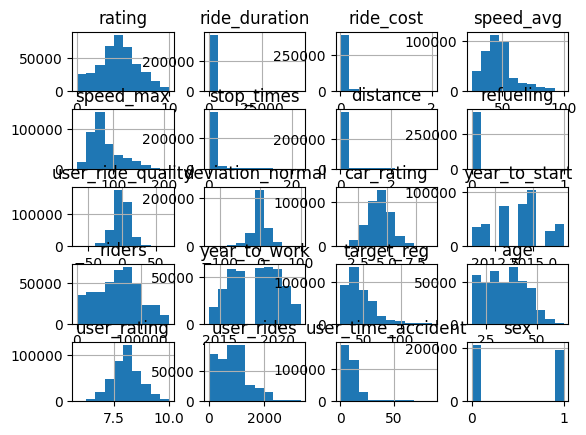

In [4]:
rides_info.hist();  # Вызываем функцию hist( )

Видно, что графики получились мелкие и текстовая информация накладывается друг на друга, также столбец пол определился как числовой, хотя является категориальным. Исправим это, добавив параметр <code>figsize</code> и отсеим ненужный столбец. Также, чтобы не выводились служебные строки перед графиками можно добавить `None` или `;` в конце ячейки.

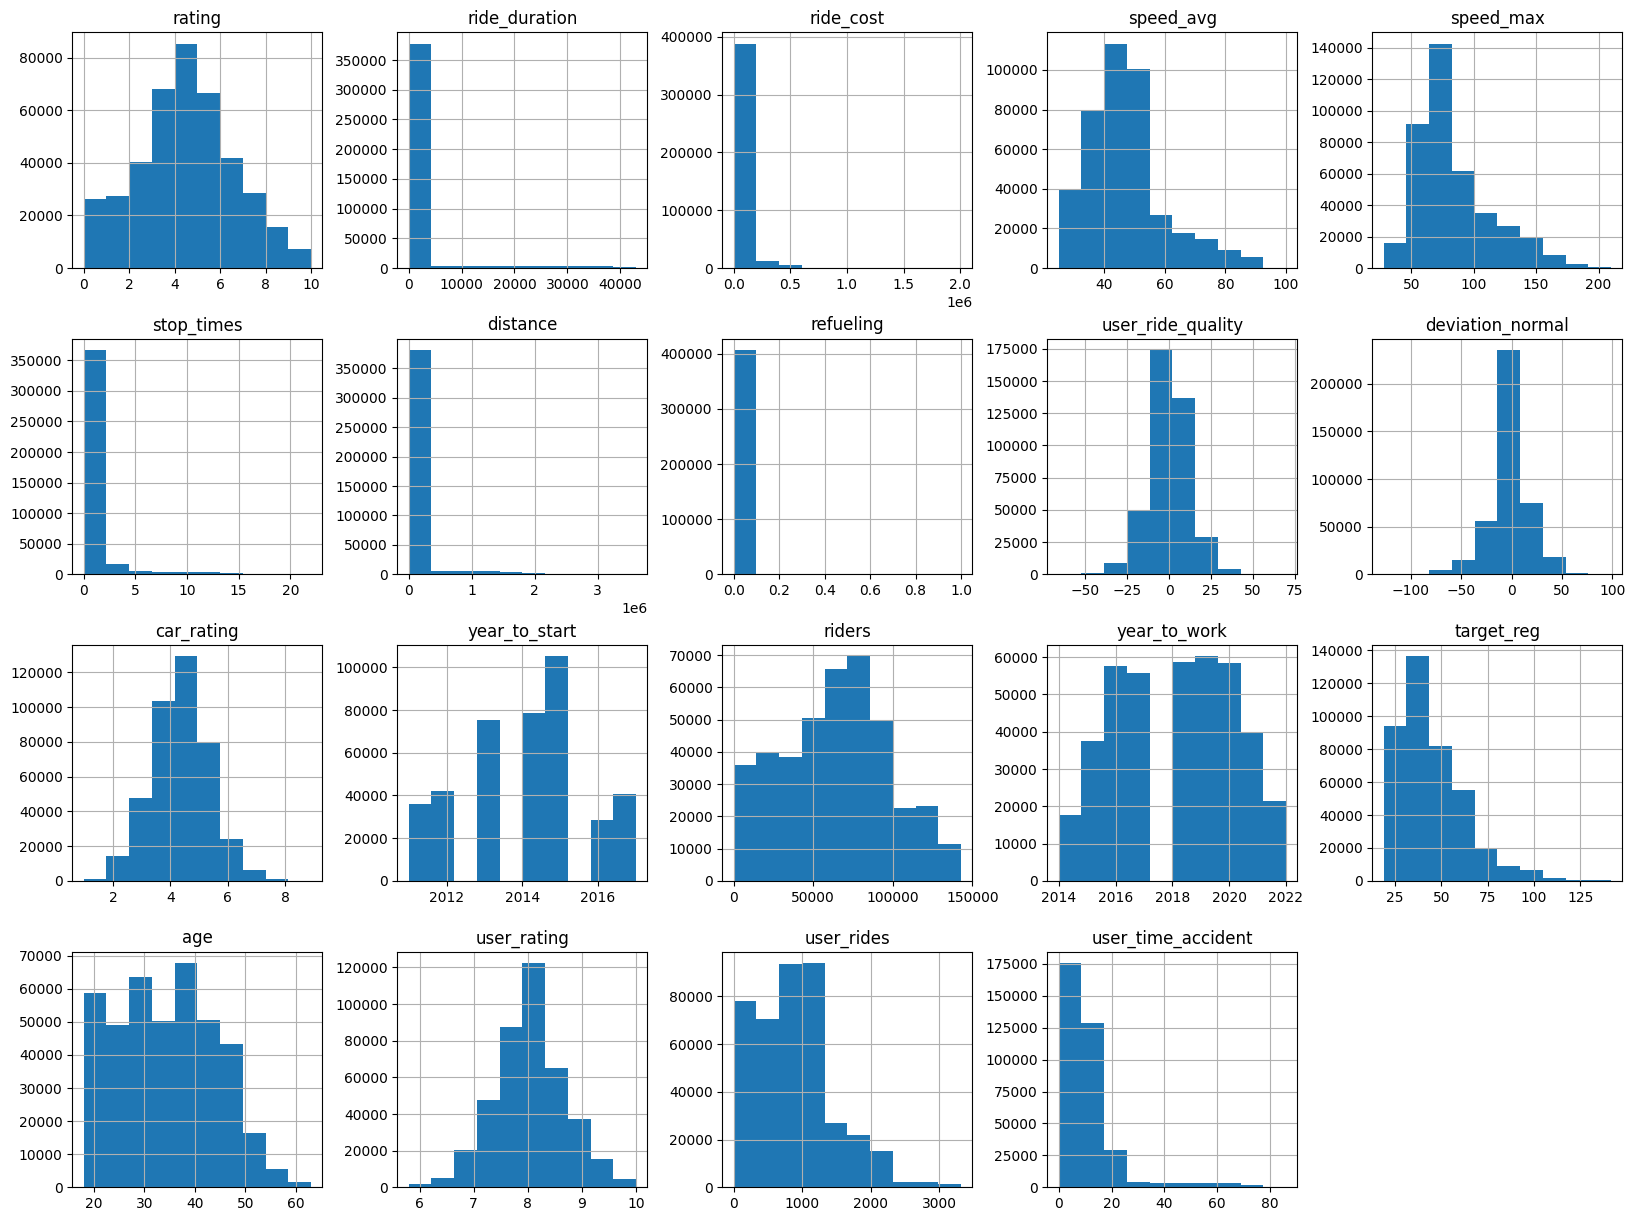

In [5]:
# Добавили ; в конце, чтобы не выводилась служебная информация
rides_info.drop("sex", axis=1).hist(figsize=(20, 15), layout=(-1, 5));

# <center><b>Распределение через боксплот `df.boxplot( )`</b></center> 

<div class="alert alert-info">
    
<code>df.boxplot( )</code> - функция, позволяющая рисовать, так называемые, "ящики с усами", показывающие среднее значение, стандартные отклонения и разброс признака на одном графике. Давайте отобразим вид поломки, в зависимоcти от рейтинга водителя, также поменяем параметр <code>fontsize</code>, отвечающий за размер шрифта.

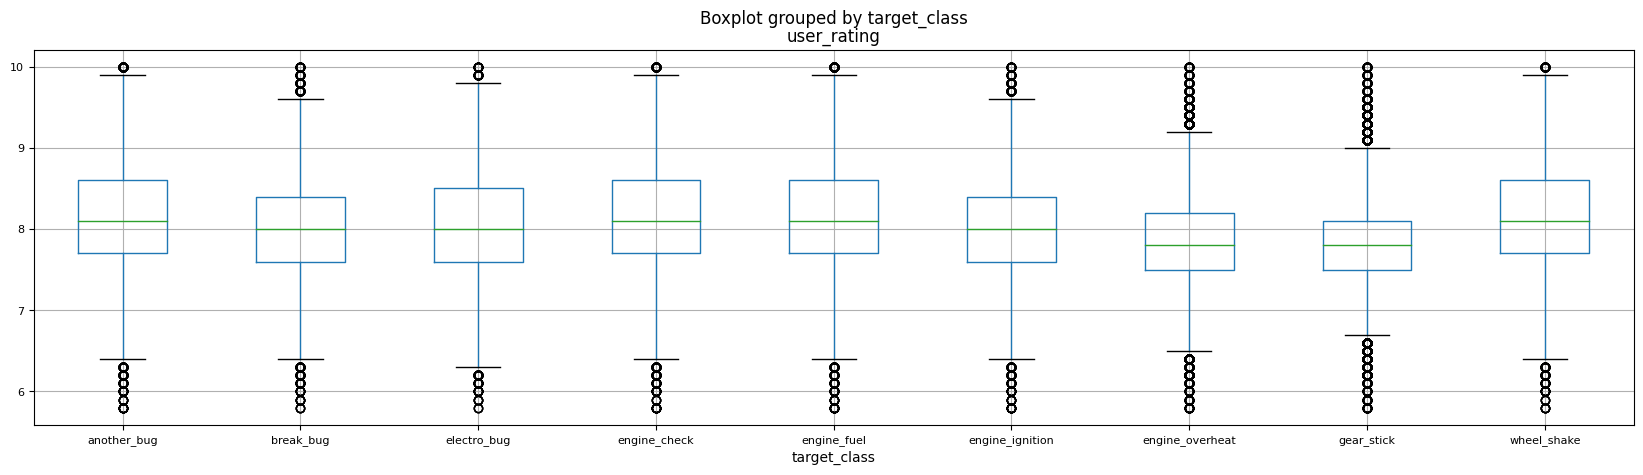

In [6]:
rides_info.boxplot(
    column=["user_rating"], by="target_class", fontsize=8, figsize=(20, 5)
);

# <center> Тепловые карты зависимостей численных и категориальных переменных </center>

In [7]:
corr = rides_info.corr(numeric_only=True).round(2)
corr.style.background_gradient(cmap="RdYlGn")

,rating,ride_duration,ride_cost,speed_avg,speed_max,stop_times,distance,refueling,user_ride_quality,deviation_normal,car_rating,year_to_start,riders,year_to_work,target_reg,age,user_rating,user_rides,user_time_accident,sex
rating,1.000000,0.000000,0.000000,-0.090000,-0.230000,-0.060000,-0.000000,0.000000,-0.000000,-0.040000,0.000000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,-0.000000
ride_duration,0.000000,1.000000,0.920000,-0.000000,0.000000,0.010000,0.960000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
ride_cost,0.000000,0.920000,1.000000,-0.000000,-0.000000,0.010000,0.880000,0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.010000,0.000000,-0.000000,-0.000000
speed_avg,-0.090000,-0.000000,-0.000000,1.000000,0.500000,-0.130000,0.060000,0.000000,-0.010000,0.040000,-0.000000,-0.000000,-0.000000,0.000000,-0.020000,0.000000,-0.000000,-0.000000,-0.020000,-0.000000
speed_max,-0.230000,0.000000,-0.000000,0.500000,1.000000,0.050000,0.030000,-0.000000,-0.010000,0.090000,0.000000,-0.010000,-0.010000,-0.000000,0.150000,-0.000000,0.010000,-0.000000,0.000000,0.000000
stop_times,-0.060000,0.010000,0.010000,-0.130000,0.050000,1.000000,-0.010000,-0.000000,0.020000,0.000000,0.020000,0.010000,0.010000,0.000000,0.190000,-0.000000,0.030000,-0.000000,0.100000,0.010000
distance,-0.000000,0.960000,0.880000,0.060000,0.030000,-0.010000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.010000,-0.000000,-0.000000,-0.000000,-0.000000,0.000000
refueling,0.000000,0.000000,0.000000,0.000000,-0.000000,-0.000000,0.000000,1.000000,0.000000,-0.000000,-0.000000,0.000000,0.000000,-0.000000,0.000000,0.000000,-0.000000,-0.000000,-0.000000,-0.000000
user_ride_quality,-0.000000,0.000000,0.000000,-0.010000,-0.010000,0.020000,0.000000,0.000000,1.000000,-0.010000,0.020000,-0.020000,-0.020000,0.020000,0.030000,-0.000000,-0.000000,0.000000,0.010000,0.000000
deviation_normal,-0.040000,-0.000000,0.000000,0.040000,0.090000,0.000000,0.000000,-0.000000,-0.010000,1.000000,0.020000,0.010000,0.010000,-0.000000,0.100000,0.000000,0.030000,0.000000,0.050000,-0.000000


In [8]:
pd.crosstab(
    rides_info["target_class"],
    rides_info["model"],
    # margins = True,
    normalize = True
).style.background_gradient(cmap="RdYlGn")

model,Audi A3,Audi A4,Audi Q3,BMW 320i,Fiat 500,Hyundai Solaris,Kia Rio,Kia Rio X,Kia Rio X-line,Kia Sportage,MINI CooperSE,Mercedes-Benz E200,Mercedes-Benz GLC,Mini Cooper,Nissan Qashqai,Renault Kaptur,Renault Sandero,Skoda Rapid,Smart Coupe,Smart ForFour,Smart ForTwo,Tesla Model 3,VW Polo,VW Polo VI,VW Tiguan,Volkswagen ID.4
target_class,,,,,,,,,,,,,,,,,,,,,,,,,,
another_bug,0.000856,0.001284,0.001284,0.000856,0.000000,0.010697,0.006846,0.008130,0.007702,0.009414,0.002567,0.000428,0.001284,0.000428,0.006846,0.006846,0.009414,0.006846,0.004707,0.008986,0.002995,0.000856,0.003851,0.008986,0.006846,0.000428
break_bug,0.001284,0.001712,0.000000,0.000428,0.001284,0.005563,0.005991,0.005563,0.005135,0.008986,0.001712,0.001284,0.000856,0.000428,0.004279,0.008558,0.008130,0.010270,0.006846,0.007702,0.006846,0.000428,0.008558,0.005563,0.007702,0.000428
electro_bug,0.001284,0.000428,0.002567,0.000428,0.000428,0.005563,0.005135,0.005991,0.007274,0.005563,0.000000,0.001284,0.002139,0.000856,0.007274,0.005991,0.005135,0.007274,0.005563,0.005563,0.008130,0.000856,0.006418,0.007702,0.005991,0.001712
engine_check,0.000856,0.001284,0.000428,0.002139,0.001284,0.007274,0.004707,0.006846,0.005563,0.007702,0.001284,0.002567,0.000000,0.001712,0.005991,0.009414,0.005135,0.008558,0.005135,0.006846,0.006418,0.000856,0.009842,0.007702,0.005991,0.000000
engine_fuel,0.000856,0.000856,0.001712,0.000428,0.000000,0.009414,0.004707,0.004707,0.007702,0.008130,0.000000,0.000856,0.000856,0.002139,0.008130,0.009414,0.009414,0.005563,0.005135,0.007702,0.005991,0.001284,0.007702,0.002995,0.005563,0.000856
engine_ignition,0.000856,0.000856,0.000428,0.001284,0.000428,0.007274,0.005135,0.008558,0.005991,0.006418,0.000856,0.000000,0.000000,0.001284,0.012837,0.004707,0.009842,0.006846,0.007274,0.008558,0.005991,0.000856,0.005135,0.006418,0.006846,0.000428
engine_overheat,0.000428,0.001284,0.001712,0.000428,0.002139,0.008558,0.004707,0.006418,0.006846,0.008130,0.001712,0.002139,0.001284,0.002139,0.009842,0.010270,0.010270,0.004279,0.004707,0.007274,0.006846,0.000000,0.006846,0.007274,0.006846,0.001284
gear_stick,0.000856,0.000856,0.000856,0.000856,0.002139,0.007702,0.005563,0.006418,0.007274,0.008558,0.000856,0.001284,0.000856,0.000428,0.007274,0.010697,0.007702,0.007274,0.006418,0.008986,0.007702,0.000856,0.006418,0.008558,0.004707,0.000428
wheel_shake,0.000000,0.000000,0.000000,0.000000,0.000000,0.006846,0.004707,0.008558,0.006418,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005991,0.004707,0.005991,0.004707,0.000000,0.005563,0.009842,0.007274,0.000000


### И все это не выходя из Pandas !

<div class="alert alert-info">
    
`df.plot( )` - функция предоставляющая весь функционал библиотеки Matplotlib, также можно через точку указывать конкретный тип желаемого графика, например: `df.plot.bar( )` или `df.plot.scatter( )`. На наш взгляд, пользоваться ей не очень удобно, поэтому не будем на ней останавливаться, подробнее можно ознакомиться в документации. Сразу перейдем к более продвинутым инструментам!

<!-- ничего -->
<!-- ничего -->
<!-- ничего -->
<!-- ничего -->
<!-- ничего -->
<!-- ничего -->
<!-- ничего -->
<!-- ничего -->
<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

# <center> `seaborn` - это все что вам надо!</center> 

<center><img src = 'https://livecodestream.dev/post/how-to-build-beautiful-plots-with-python-and-seaborn/featured.jpg' width=800 height = 400></center> 

In [9]:
import seaborn as sns

sns.set_theme()  # Тут можно задать стили

# <center>`sns.scatterplot()` + `sns.lineplot()` + 💪 =  `sns.relplot`(`kind = ...`) </center> 

<div class="alert alert-info">
    
Функция `relplot()` объединяет в себе функционал `scatterplot()` (диаграмма рассеяния) и `lineplot()`, смена происходит переключателем `kind`. <br>
Таким образом можно держать в голове меньше разных названий функций и параметров. 

Более того, `plt.figure(figsize=(20, 5)) ` больше не нужен, ведь есть параметры `height` и `aspect`. 

Диаграмма рассеяния — это диаграмма, которая отображает точки на основе двух измерений набора данных.

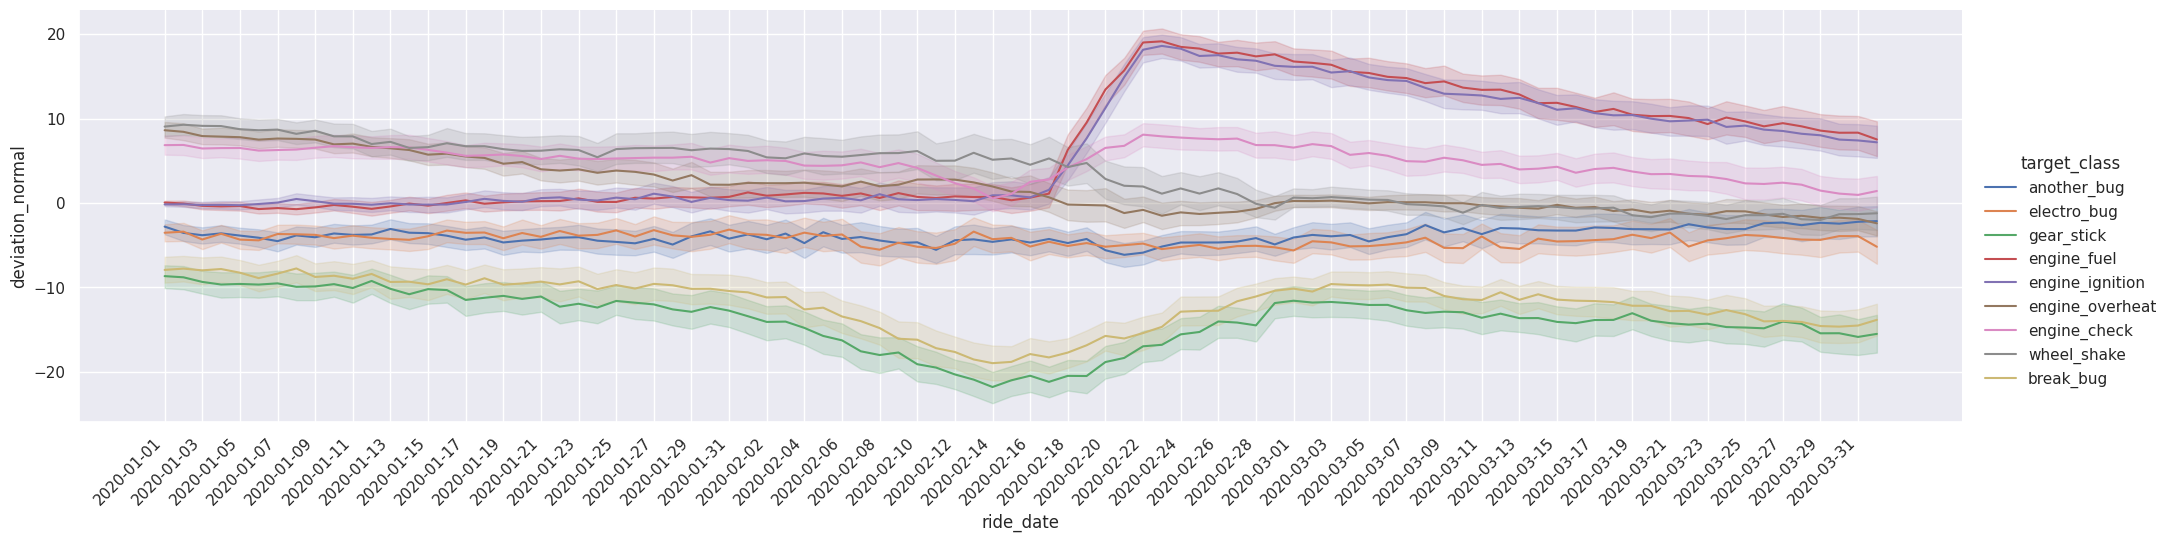

In [10]:
g = sns.relplot(
    data=rides_info,
    x="ride_date",
    y="deviation_normal",
    hue="target_class",
    kind="line",  # или scatter
    aspect=4,
)

g.set_xticklabels(rotation=45, horizontalalignment="right", step=2);

<div class="alert alert-info">

По оси `х` мы вытянули время. По оси `y` исследуемый столбец, в данном случае `deviation_normal`. Все точки окрасили в соответствующий класс для наглядности. 
    
Становится видно, что величина `deviation_normal` ведет себя по-разному в зависимости от класса будущей поломки. Например, точку перегиба в центре графика для класса `engine_ignition` можно использовать как вспомогательный признак.

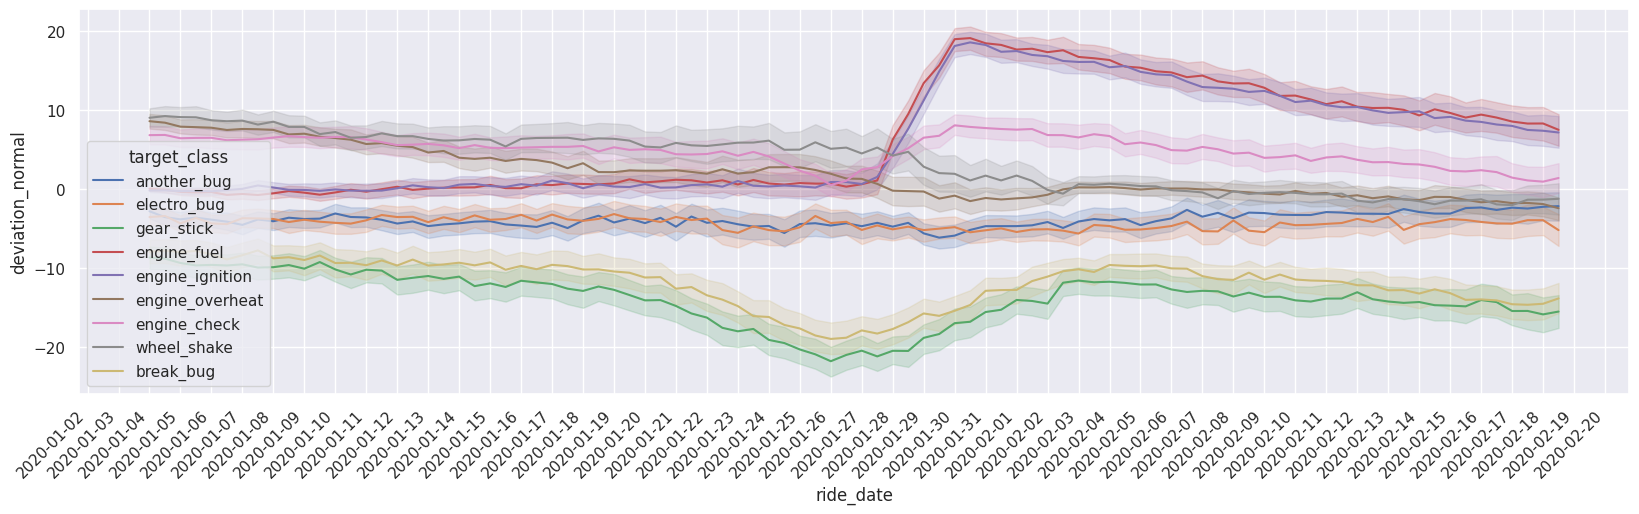

In [11]:
# Импортируем вспомогательные фрагменты из matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(20, 5))

g = sns.lineplot(
    data=rides_info,
    x="ride_date",
    y="deviation_normal",
    hue="target_class",
)

g.set_xticklabels(g.get_xticklabels(), rotation=45, horizontalalignment="right")
g.xaxis.set_major_locator(ticker.MultipleLocator(2));

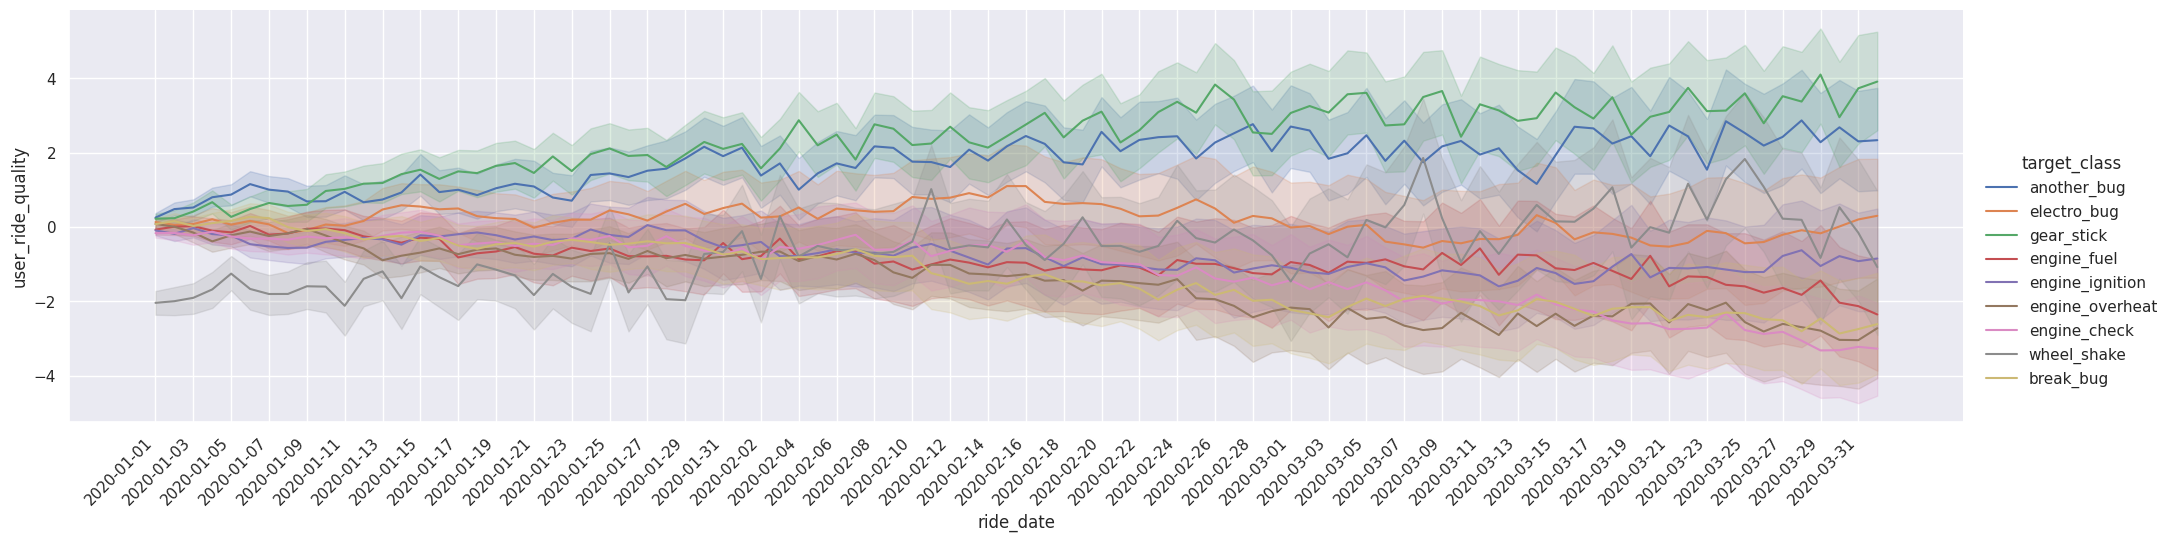

In [12]:
g = sns.relplot(
    data=rides_info,
    x="ride_date",
    y="user_ride_quality",
    kind="line",
    hue="target_class",
    aspect=4,
)

g.set_xticklabels(rotation=45, horizontalalignment="right", step=2);

<div class="alert alert-info">

Аналогично растянули признак `user_ride_quality` во времени по оси `y` как исследуемый столбец. Все точки мы окрасили в соответствующий класс для наглядности. 
    
Заметно, что величина `user_ride_quality` ведет себя по-разному в зависимости от класса будущей поломки. Например, стартовая точка у разных классов находится на разной высоте. 

In [13]:
# Отберем информацию только про 10 машин
tmp = rides_info[rides_info["car_id"].isin(rides_info.car_id.unique()[:10])]

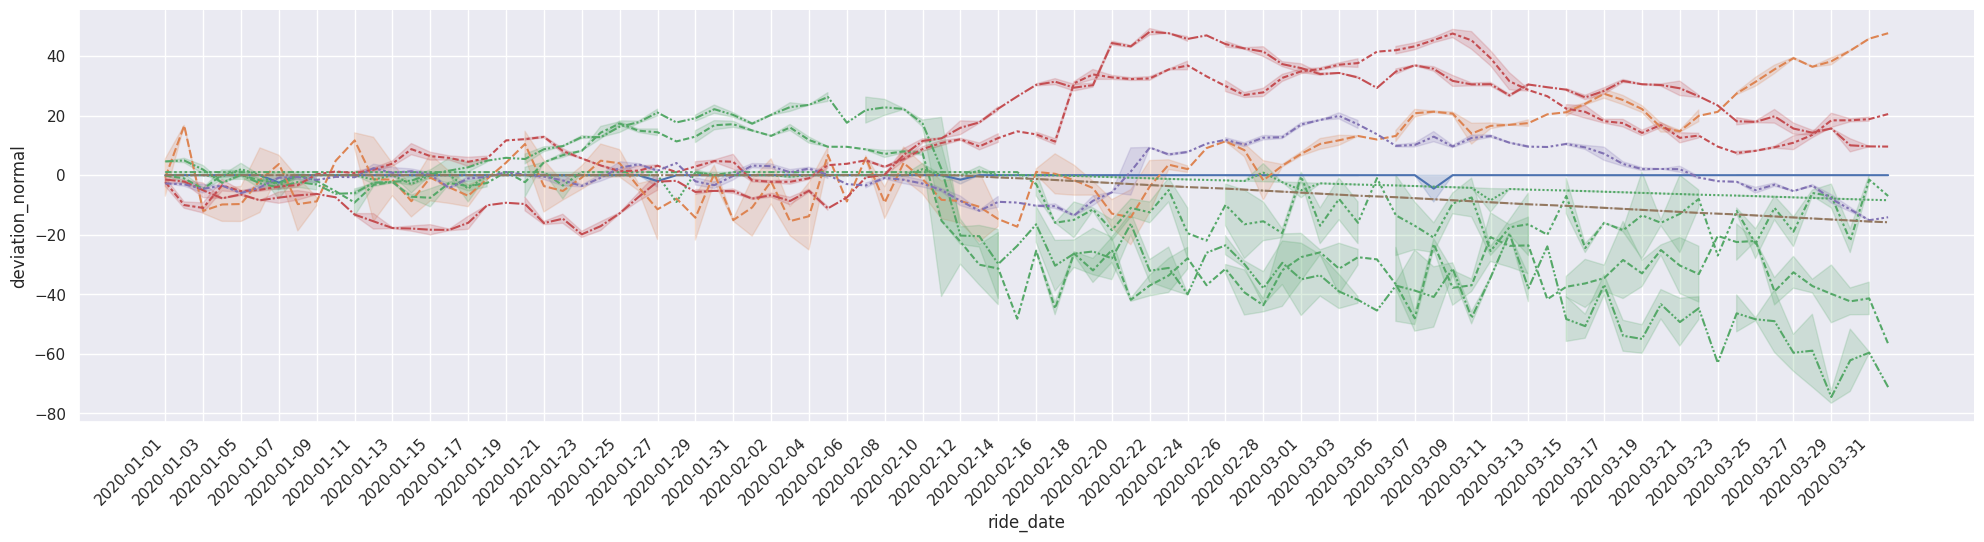

In [14]:
# Как ведет себя deviation_normal во времени для 10 автомобилей

g = sns.relplot(
    data=tmp,
    
    x="ride_date",
    y="deviation_normal",
    
    hue="target_class",
    style="car_id",
    
    legend=False,
    kind="line",
    aspect=4,
)
g.set_xticklabels(rotation=45, horizontalalignment="right", step=2)

<div class="alert alert-info">
    
### Какие признаки могут помочь различить классы поломок?
* Замечаем точки перегиба
* Замечаем точки входа
* Возможно углы наклона до перегиба
    
### Все это можно можно будет использовать, как доп. признаки!


In [15]:
# Вместо известного нам:

# plt.figure(figsize=(20, 5))
# sns.scatterplot(data = rides_info,
#                  x = 'ride_duration',
#                  y = 'ride_cost',
#                  hue = 'model'
#                 );

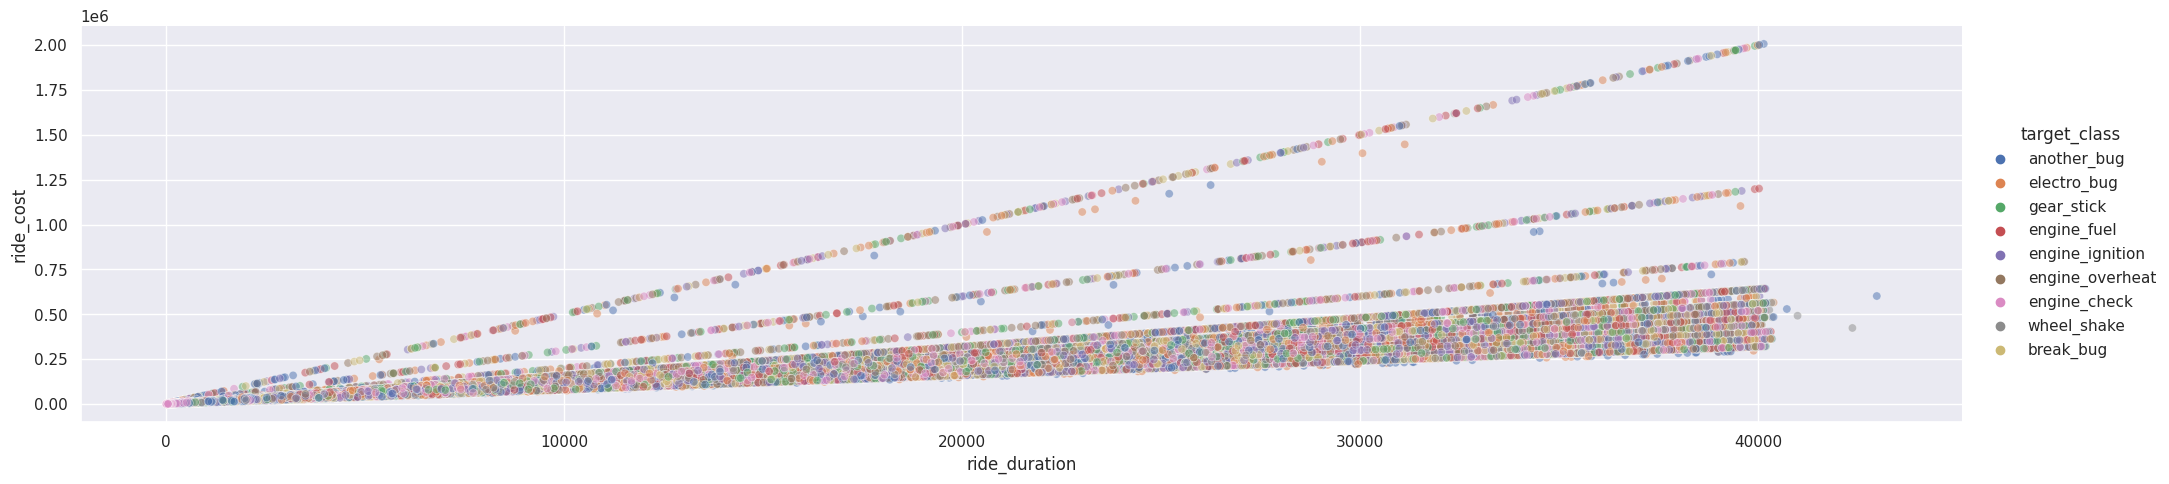

In [16]:
g = sns.relplot(
    data=rides_info,
    x="ride_duration",
    y="ride_cost",
    hue="target_class",
    
    kind="scatter",
    aspect=4,
    alpha=0.5,
);

<div class="alert alert-info">
    
С помощью более функционального `sns.relplot()` пишем меньше кода и быстрее анализируем. Кстати, по графику заметно, что угол наклона у разных машин разный.
    
Возможно `feature = ride_cost/ride_duration` - это отличный доп.признак!   
    
Имеет смысл поиграть с такими параметрами как `row` и `col`, чтобы построить этот график в разрезах по другим категориальным признакам

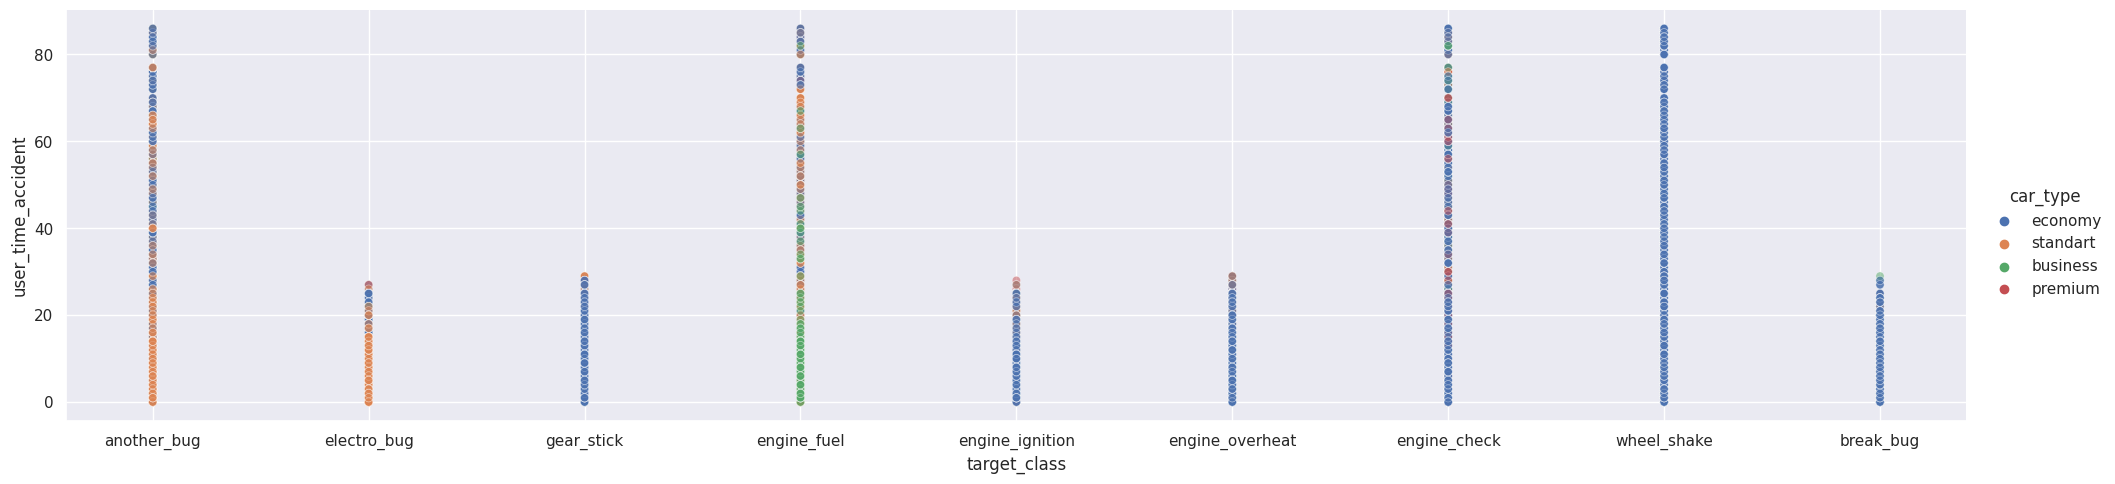

In [17]:
g = sns.relplot(
    data=rides_info,
    x="target_class",
    
    y="user_time_accident",
    
    hue="car_type",
    kind="scatter",
    aspect=4,
    alpha=0.5,
);

<div class="alert alert-info">
    
Запоминайте, полезно растягивать исследуемые признаки не только вдоль времени или численных признаков, но еще и по категориальным переменным.
    
В этом примере по оси `X` таргет, а цветом окрашен сегмент машины.

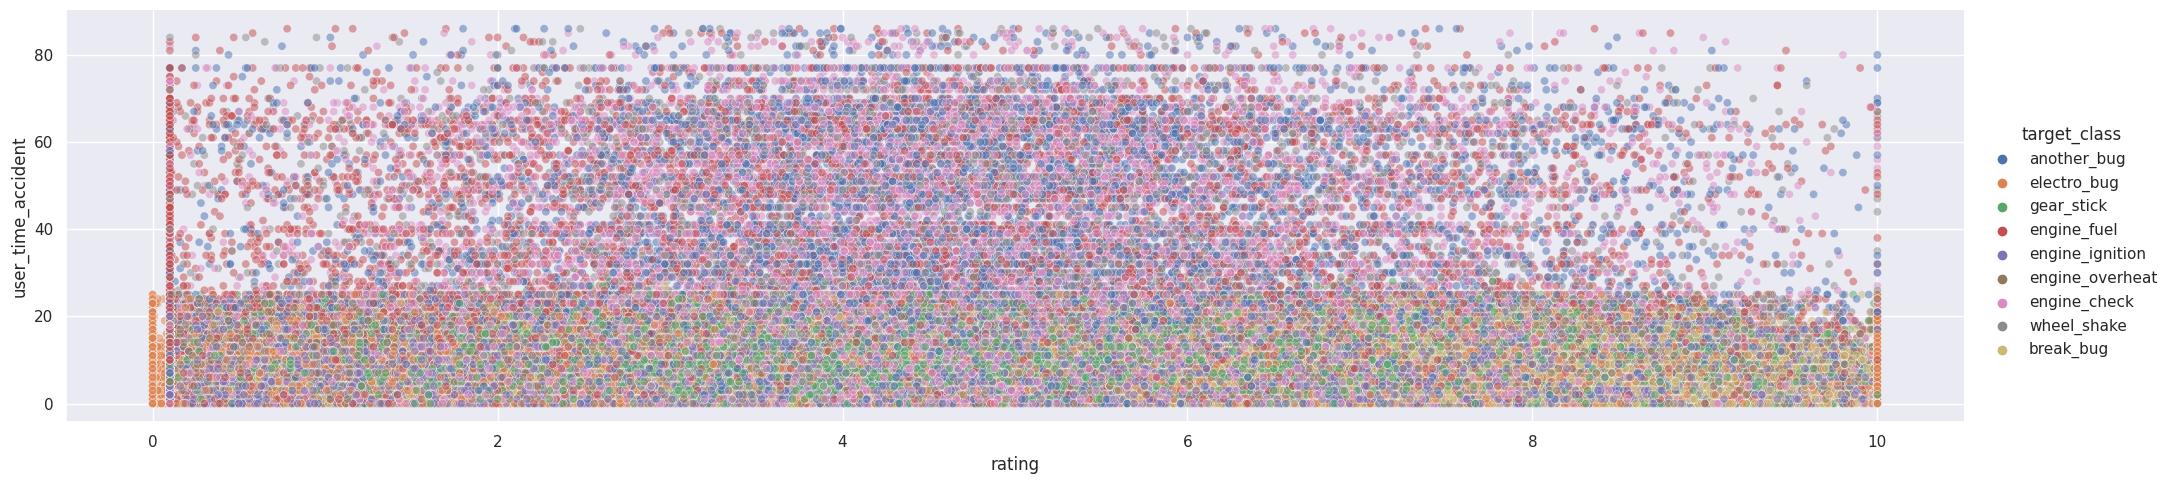

In [18]:
sns.relplot(
    data=rides_info,
    x="rating",
    y="user_time_accident",
    hue="target_class",
    kind="scatter",
    aspect=4,
    alpha=0.5,
);

<div class="alert alert-info">

Еще один интересный инсайт того, как число инцидентов водителя зависит от его рейтинга.

Легко заметить, что некоторые классы поломок свойственны поездкам с низким рейтингом.
    
🧠 Очень рекомендуем применять метод `sns.relplot()`.

# Чтобы эффективнее исследовать данные:

* 🔴 Растягивайте исследуемый признак во времени 
* 🟢 Стройте признак относительно другого признака / частоты
* 🟡 Раскрашивайте точки в категории / таргет (параметры: `hue` / `style` / `size`)

<!-- ничего -->

# <!-- ничего -->

<!-- ничего -->

<!-- ничего -->

# <center>🔥 Построение распределений и <b> sns.displot() 🔥</b></center>

## <center> <b> `sns.displot`(`kind=...`) = `sns.histplot()`  + `kdeplot()` + `ecdfplot()` + 💪 </center>

<div class="alert alert-info">
    
В `Seaborn` функция `displot()` объединяет в себе функционал `histplot()`, `kdeplot()` и `ecdfplot()`, переключение происходит с помощью `kind`. <br>
Получается, что снова можно держать в голове меньше разных названий функций и параметров. И снова `plt.figure(figsize=(20, 5)) ` не нужен, ведь есть параметры `height` и `aspect`.

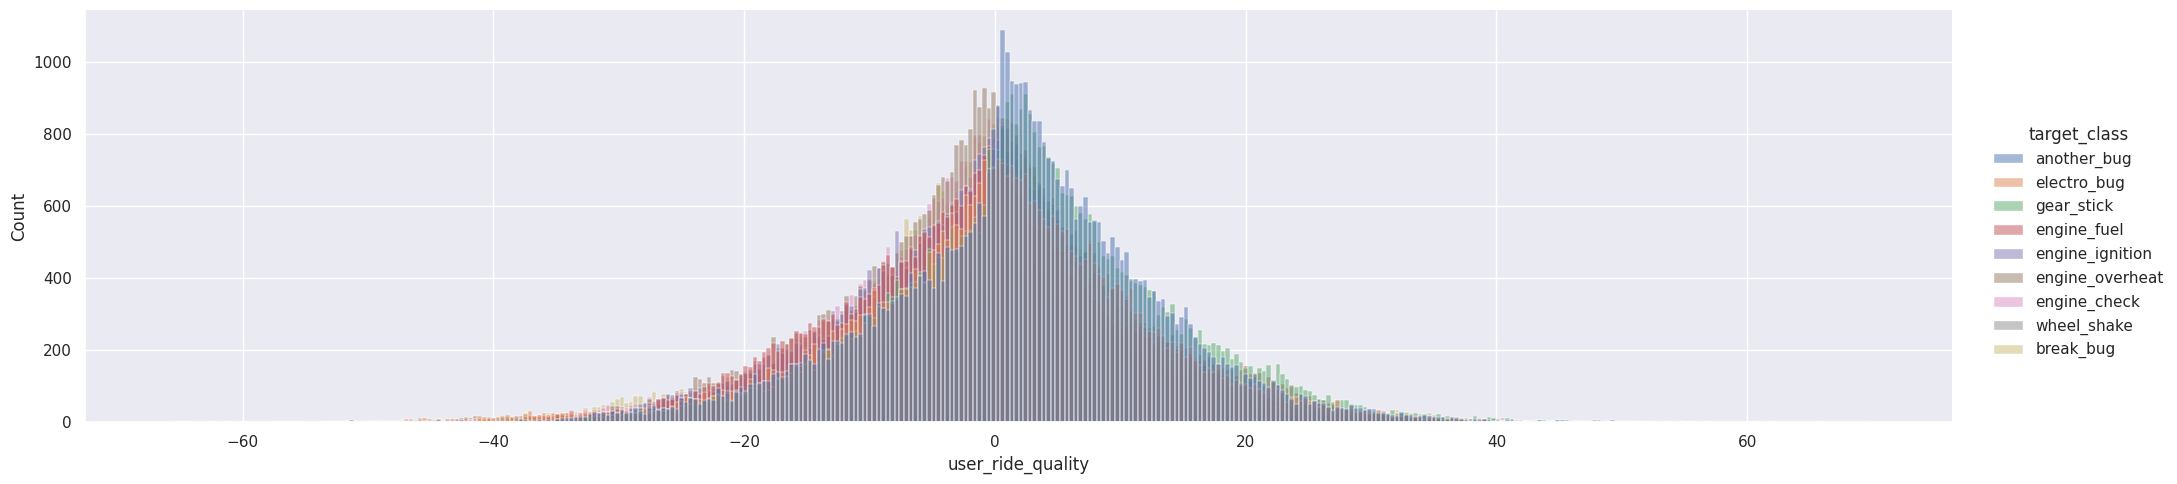

In [19]:
# plt.figure(figsize=(20, 5)) # уже можно не использовать, ведь есть параметр aspect

tmp = rides_info[rides_info["car_id"].isin(rides_info.sample(100).car_id.unique()[:20])]

g = sns.displot(
    data=rides_info,
    
    x="user_ride_quality",
    # y="user_time_accident",
    
    hue="target_class",
    legend=True,
    aspect=4,
    kind="hist",  # kde
    alpha=0.5,
);

<div class="alert alert-info">

 🧠 🧠 Многофункциональный метод `sns.displot()` - это вторая вещь, после `sns.relplot()`, которую вам нужно запомнить и использовать при возможности!

In [20]:
tmp = rides_info[rides_info["car_id"].isin(rides_info.sample(100, random_state=10).car_id.unique()[:20])]

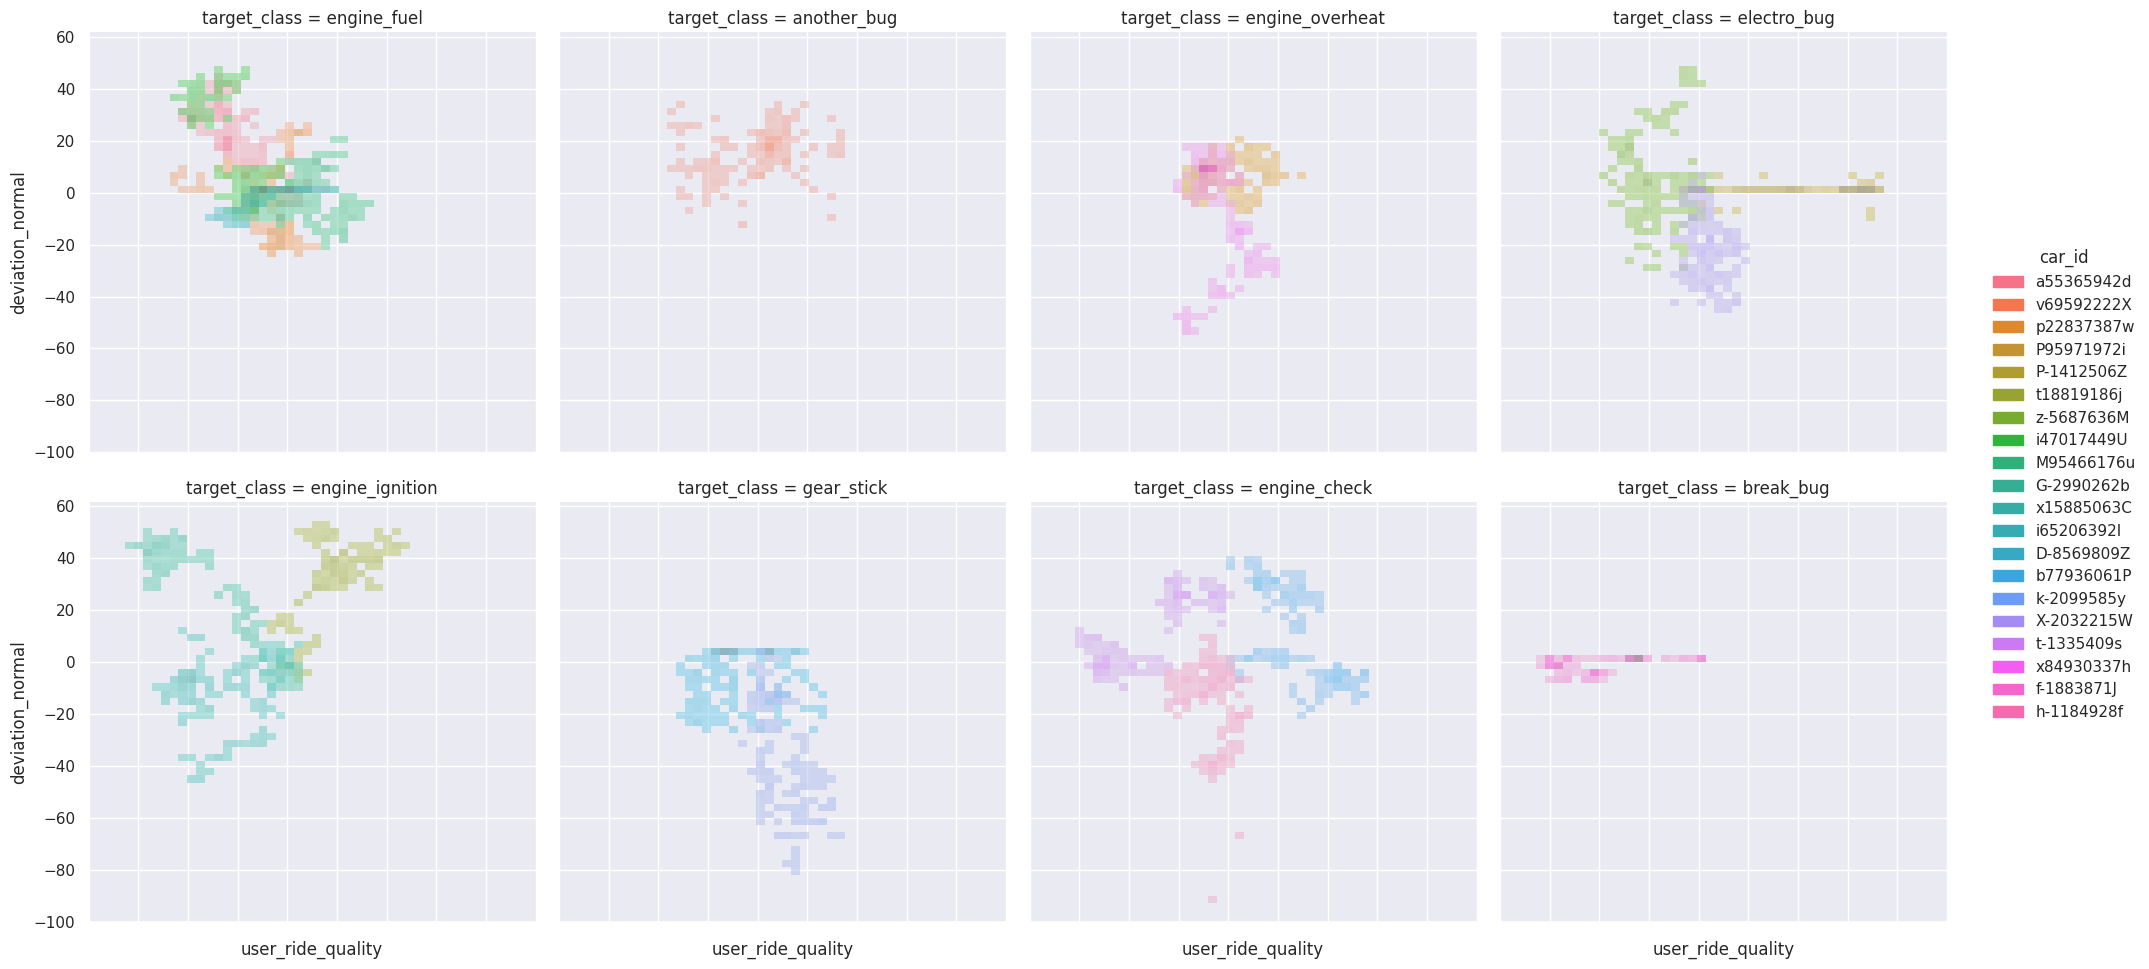

In [21]:
g = sns.displot(
    data=tmp,
    
    x="user_ride_quality",
    y="deviation_normal",
    
    aspect=1,
    # kind="kde",
    alpha=0.5,
    
    hue="car_id",
    col="target_class",
    
    col_wrap=4,
    
).set_xticklabels(rotation=45, horizontalalignment="right");

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

# <center> 🔥 Категориальные данные и <b> `sns.catplot()`</b></center>

<div class="alert alert-info">
    
В Seaborn функция `catplot()` объединяет в себе функционал `boxplot()`, `violinplot()`, `boxenplot`, `stripplot`, `swarmplot`, а еще `pointplot`, `barplot` и `countplot`. Переключение происходит параметром `kind`. <br>
Получается, что снова можно держать в голове меньше разных названий функций и параметров.

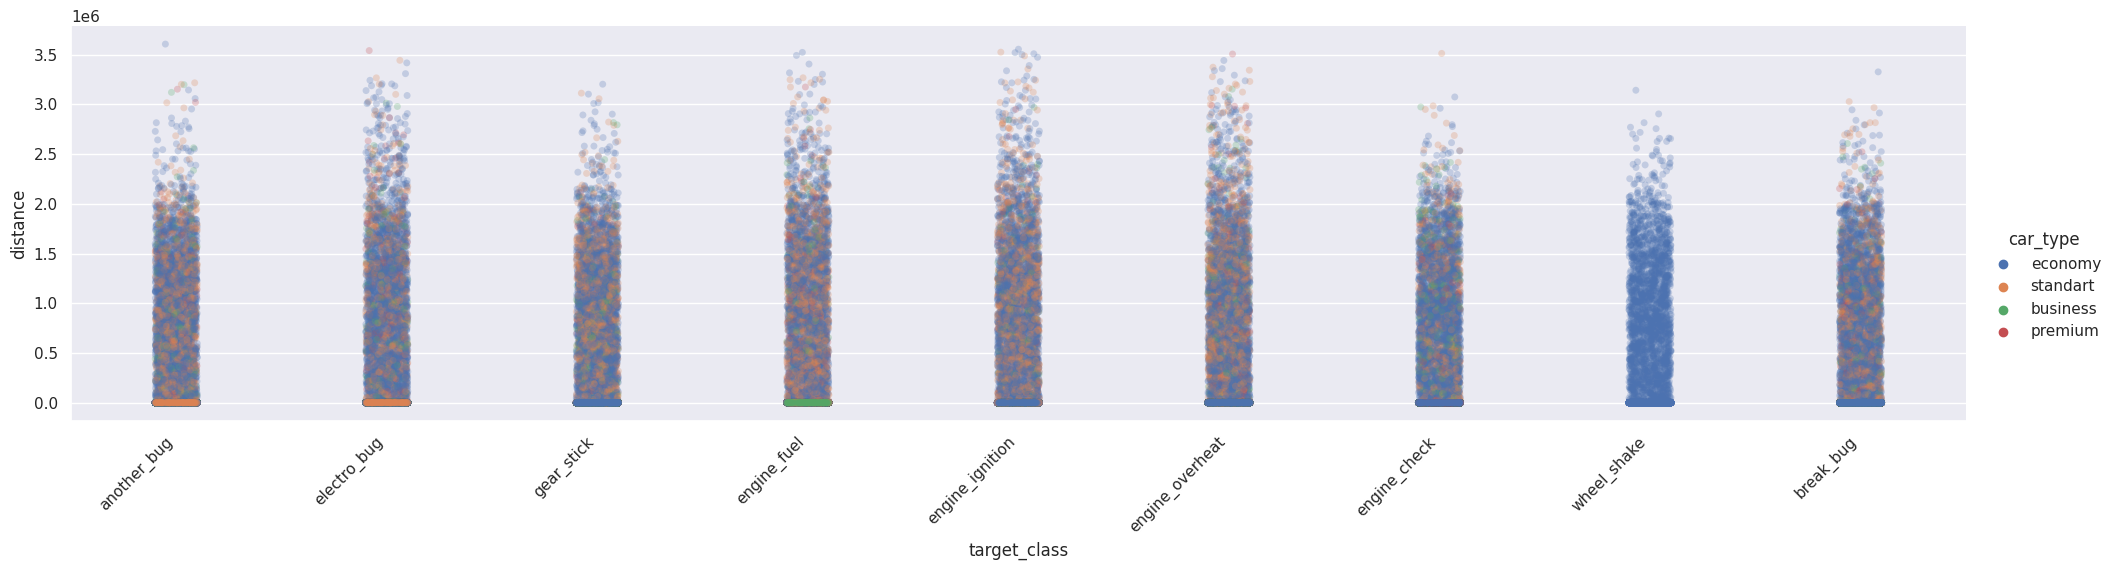

In [22]:
sns.catplot(
    data=rides_info,
    x="target_class",
    y="distance",
    
    aspect=4,
    hue="car_type",
    alpha=0.25,
    
).set_xticklabels(rotation=45, horizontalalignment="right");

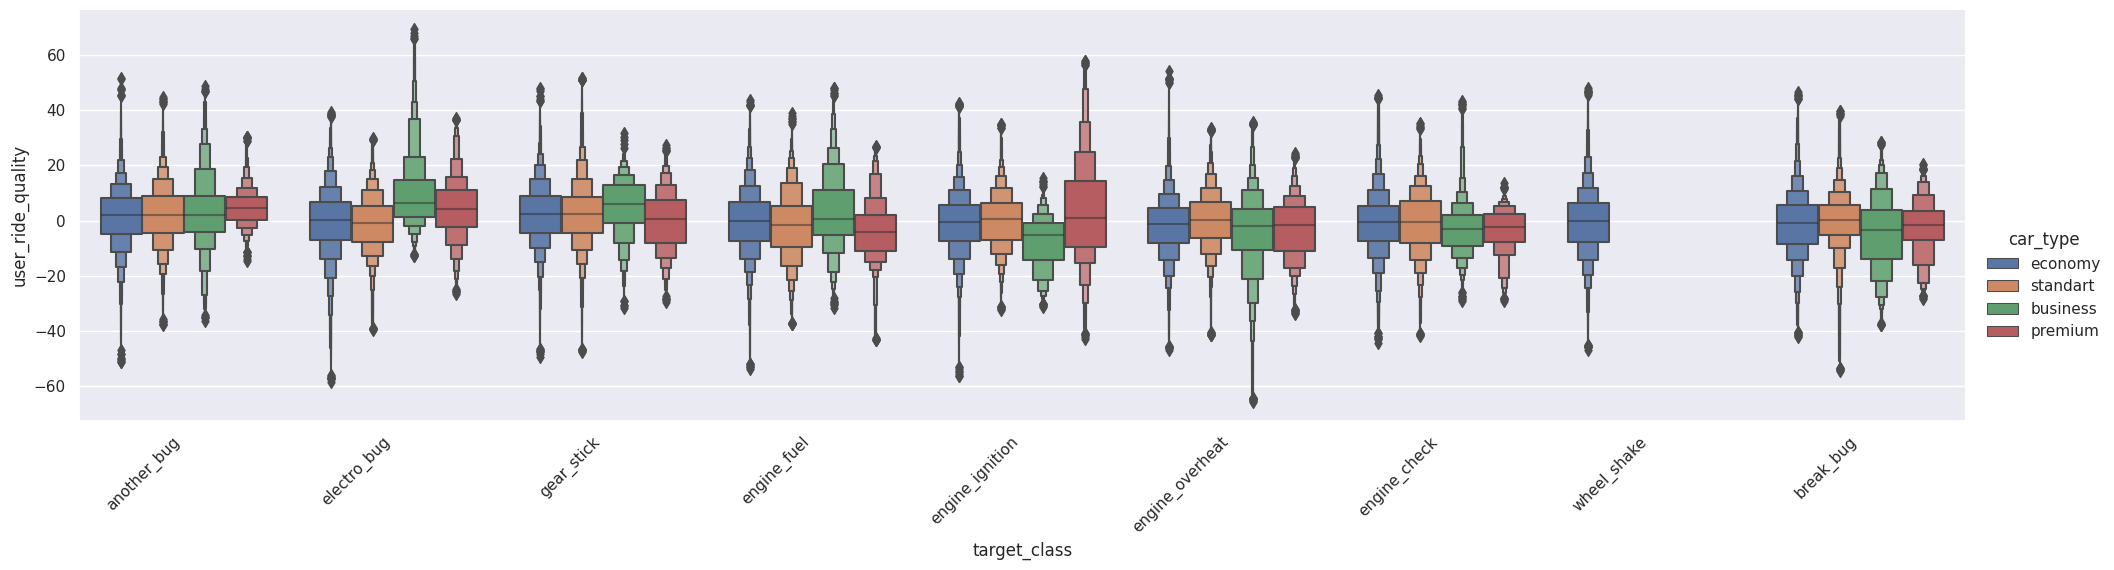

In [23]:
# Варьируем в параметр kind, получаем любой вид графики

sns.catplot(
    data=rides_info,
    x="target_class",
    y="user_ride_quality",
    hue="car_type",
    aspect=4,
    kind="boxen",
).set_xticklabels(rotation=45, horizontalalignment="right");

<div class="alert alert-info">

__Вывод:__ Сходу замечаем, что поломки класса `wheel_shake` не происходят в трех сегментах машин.     
    
🧠 🧠 🧠  Многофункциональный метод `sns.catplot()` это третья вещь, после `sns.displot()` и `sns.relplot()`, которую вам нужно запомнить и использовать при возможности!

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

<!-- ничего -->

# <center>🔥 Попарные корреляции и тепловая карта - <b> `sns.heatmap()`</b> </center>

<div class="alert alert-info">
    
Функция `sns.heatmap()`  чаще всего используется для отрисовки наглядной матрицы корреляций признаков. Хотя можно её использовать, когда хочется подсветить какую угодно таблицу значений. 
    
Посмотрим как её построить на нашем датасете. Сначала посмотрим матрицу корреляций, которую выводит `pandas`:

In [24]:
rides_info.corr(numeric_only=True)

,rating,ride_duration,ride_cost,speed_avg,speed_max,stop_times,distance,refueling,user_ride_quality,deviation_normal,car_rating,year_to_start,riders,year_to_work,target_reg,age,user_rating,user_rides,user_time_accident,sex
rating,1.000000,0.001227,0.001568,-0.086294,-0.234631,-0.055198,-0.003871,0.001678,-0.000310,-0.042613,0.003083,0.000846,0.000837,0.000607,-0.003452,0.002053,0.003308,-0.002442,0.000104,-0.004693
ride_duration,0.001227,1.000000,0.915057,-0.001735,0.000430,0.009862,0.964560,0.004879,0.000633,-0.000385,0.000894,0.000103,0.000352,-0.000472,-0.002801,-0.002866,-0.000477,-0.000353,-0.001229,0.001111
ride_cost,0.001568,0.915057,1.000000,-0.001216,-0.000034,0.007818,0.882981,0.004250,0.001506,0.000323,-0.000041,0.002257,0.002378,0.004566,0.007067,0.000046,0.005591,0.001068,-0.000278,-0.000168
speed_avg,-0.086294,-0.001735,-0.001216,1.000000,0.496602,-0.129687,0.064636,0.000575,-0.007180,0.040983,-0.004753,-0.001666,-0.002308,0.000170,-0.024530,0.001540,-0.002659,-0.000611,-0.022754,-0.000349
speed_max,-0.234631,0.000430,-0.000034,0.496602,1.000000,0.051144,0.032024,-0.000847,-0.008618,0.087402,0.000648,-0.012698,-0.014007,-0.003338,0.149425,-0.001196,0.006604,-0.001281,0.004410,0.002147
stop_times,-0.055198,0.009862,0.007818,-0.129687,0.051144,1.000000,-0.006981,-0.000387,0.020246,0.004780,0.018989,0.008198,0.009124,0.002615,0.193921,-0.003088,0.032055,-0.001420,0.098434,0.005554
distance,-0.003871,0.964560,0.882981,0.064636,0.032024,-0.006981,1.000000,0.003681,0.000124,0.002246,0.000241,0.000411,0.000757,0.000053,-0.005720,-0.002923,-0.000643,-0.000154,-0.003351,0.001479
refueling,0.001678,0.004879,0.004250,0.000575,-0.000847,-0.000387,0.003681,1.000000,0.001204,-0.001345,-0.002619,0.002083,0.001635,-0.003023,0.000861,0.001442,-0.000931,-0.001680,-0.001183,-0.002582
user_ride_quality,-0.000310,0.000633,0.001506,-0.007180,-0.008618,0.020246,0.000124,0.001204,1.000000,-0.011180,0.018024,-0.019891,-0.020917,0.021576,0.025973,-0.003643,-0.002574,0.001516,0.005087,0.003929
deviation_normal,-0.042613,-0.000385,0.000323,0.040983,0.087402,0.004780,0.002246,-0.001345,-0.011180,1.000000,0.021623,0.009543,0.012239,-0.004786,0.100291,0.000671,0.027107,0.000613,0.054867,-0.000229


<div class="alert alert-info">
    
Можно ориентироваться, но достаточно сложно при большом количестве признаков. <br>
Теперь отрисуем матрицу с помощью `sns.heatmap( )`:

In [25]:
# Размер будущей тепловой карты. Можно указать в коде разово
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12, 12)

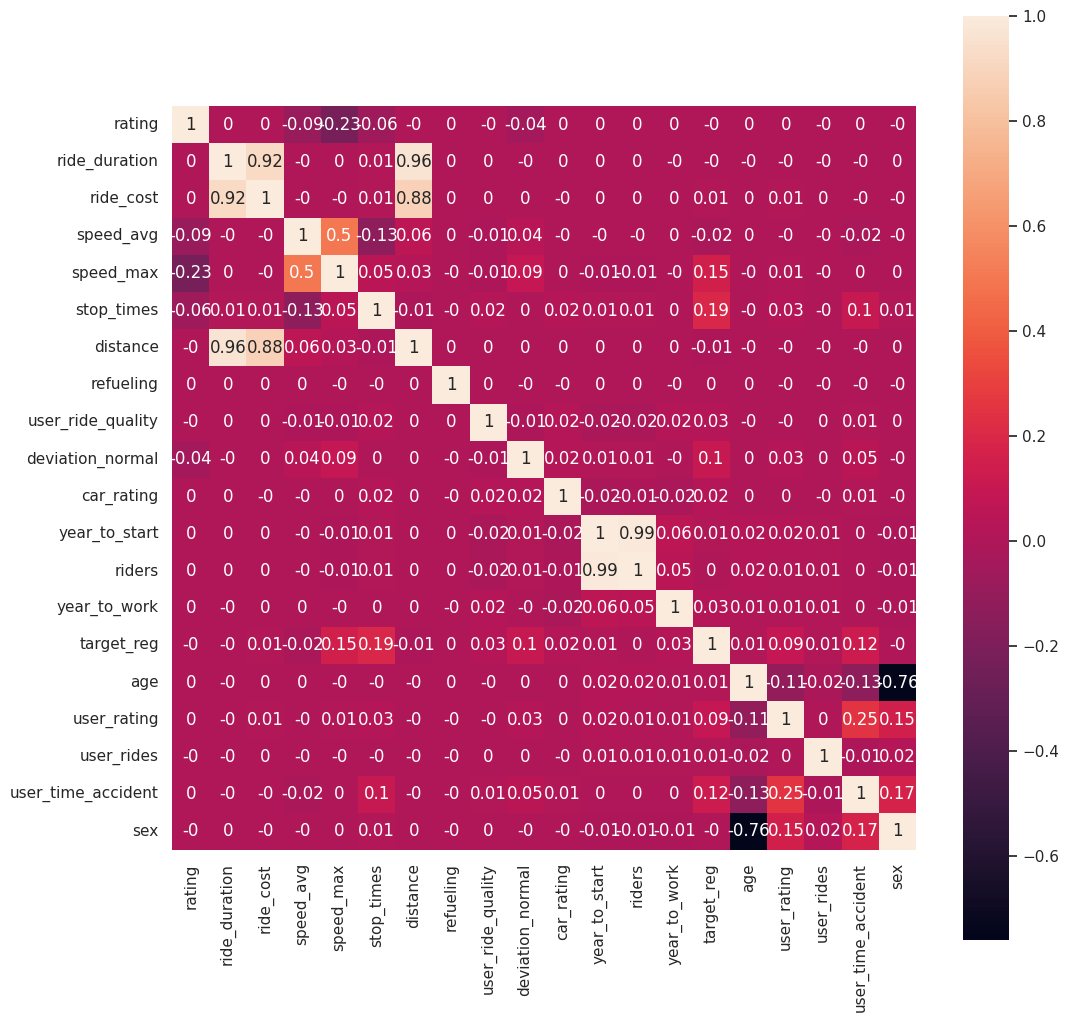

In [26]:
sns.heatmap(
    data=rides_info.corr(numeric_only=True).round(2),
    square=True,
    annot=True,
);

## Добавим красоты

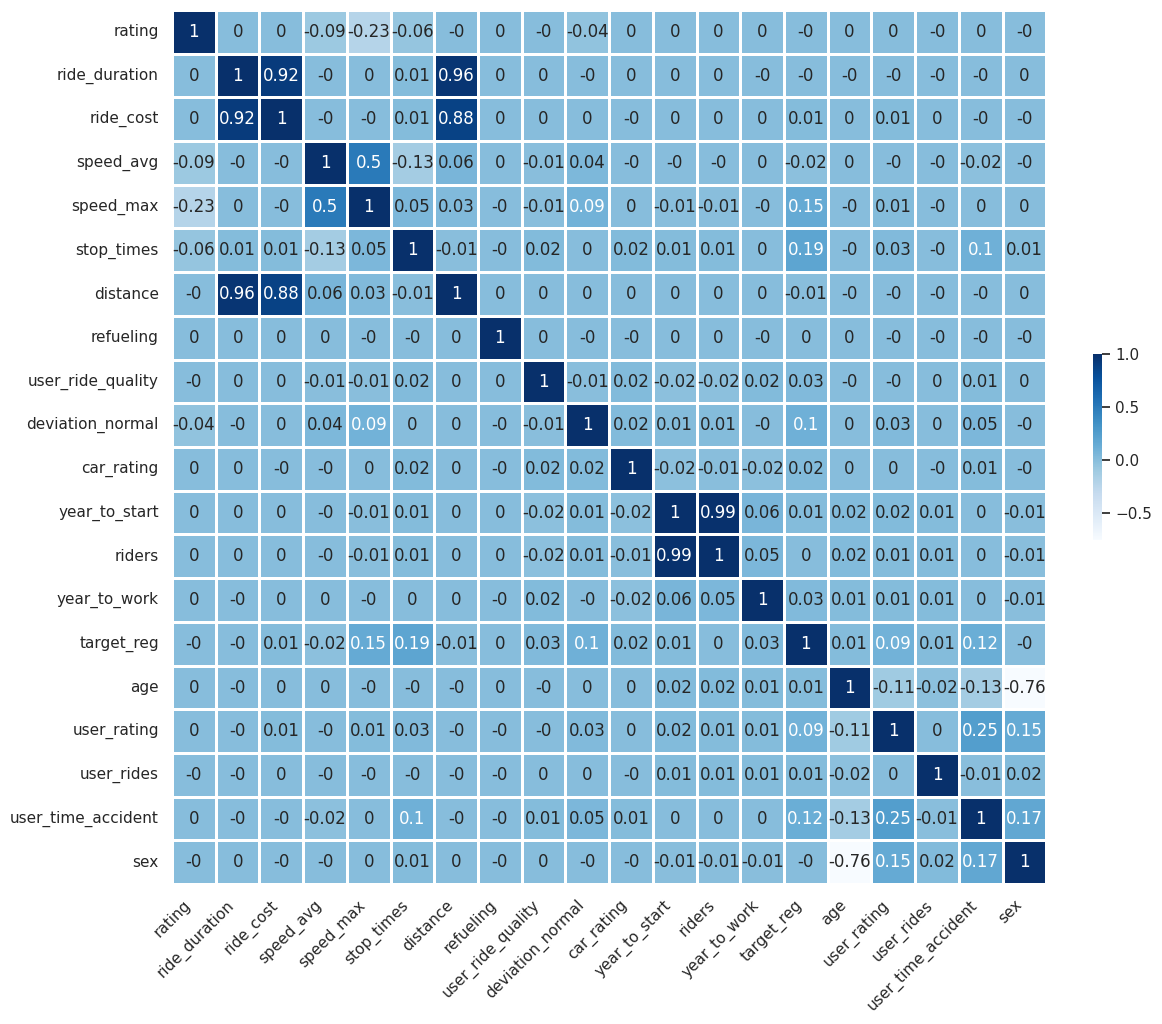

In [27]:
heatmap = sns.heatmap(
    rides_info.corr(numeric_only=True).round(2),
    annot=True,
    square=True,
    
    cmap="Blues",  # использовать синюю цветовую карту
    cbar_kws={"fraction": 0.01},  # боковой колор-бар (shrink colour bar)
    linewidth=2,  # пространство между клетками
)

heatmap.set_xticklabels(
    heatmap.get_xticklabels(), rotation=45, horizontalalignment="right"
);

<div class="alert alert-info">
    
Видно, что части снизу и сверху от диагонали идентичны, и новой информации не несут, создавая визуальный шум - уберем одну из них

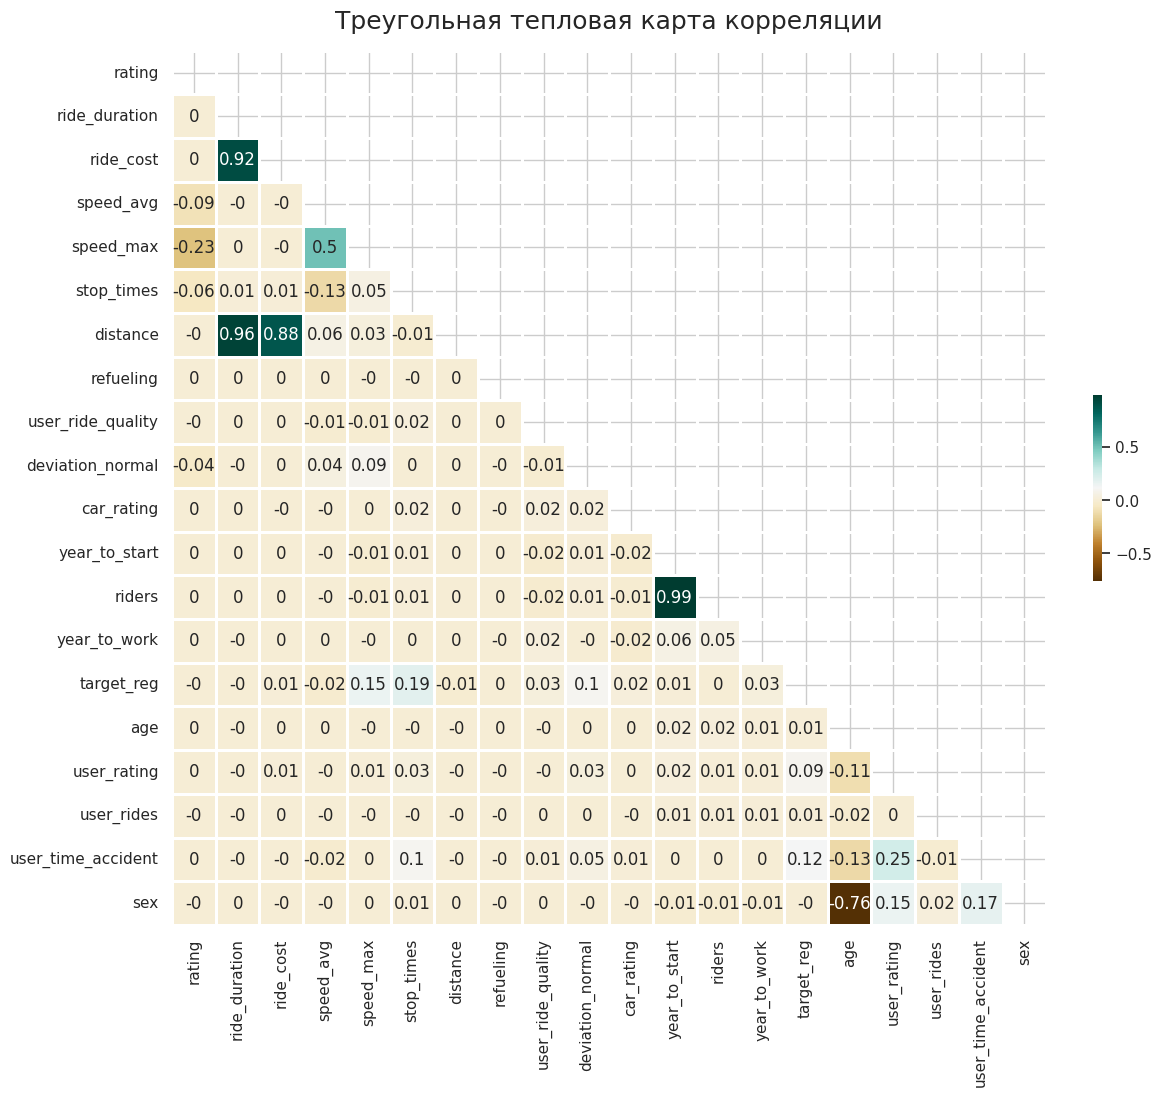

In [28]:
sns.set_style("whitegrid")

# Воспользуемся функциями np.triu, чтобы изолировать верхний треугольник (np.tril нижний)
# функция np.ones_like() изменит все изолированные значения на 1.
mask = np.triu(np.ones_like(rides_info.corr(numeric_only=True), dtype=bool))

heatmap = sns.heatmap(
    rides_info.corr(numeric_only=True).round(2),
    annot=True,
    square=True,
    cmap="BrBG",
    cbar_kws={"fraction": 0.01},
    linewidth=1,
    
    mask=mask,
)

heatmap.set_title(
    "Треугольная тепловая карта корреляции", fontdict={"fontsize": 18}, pad=16
);

<!-- ничего -->

<!-- ничего -->

# <center>Связка  `pd.crosstab` + `sns.heatmap` = 🔥 </center> 

In [29]:
# Размер будущей тепловой карты. Можно указать в коде разово
plt.rcParams["figure.figsize"] = (25, 25)

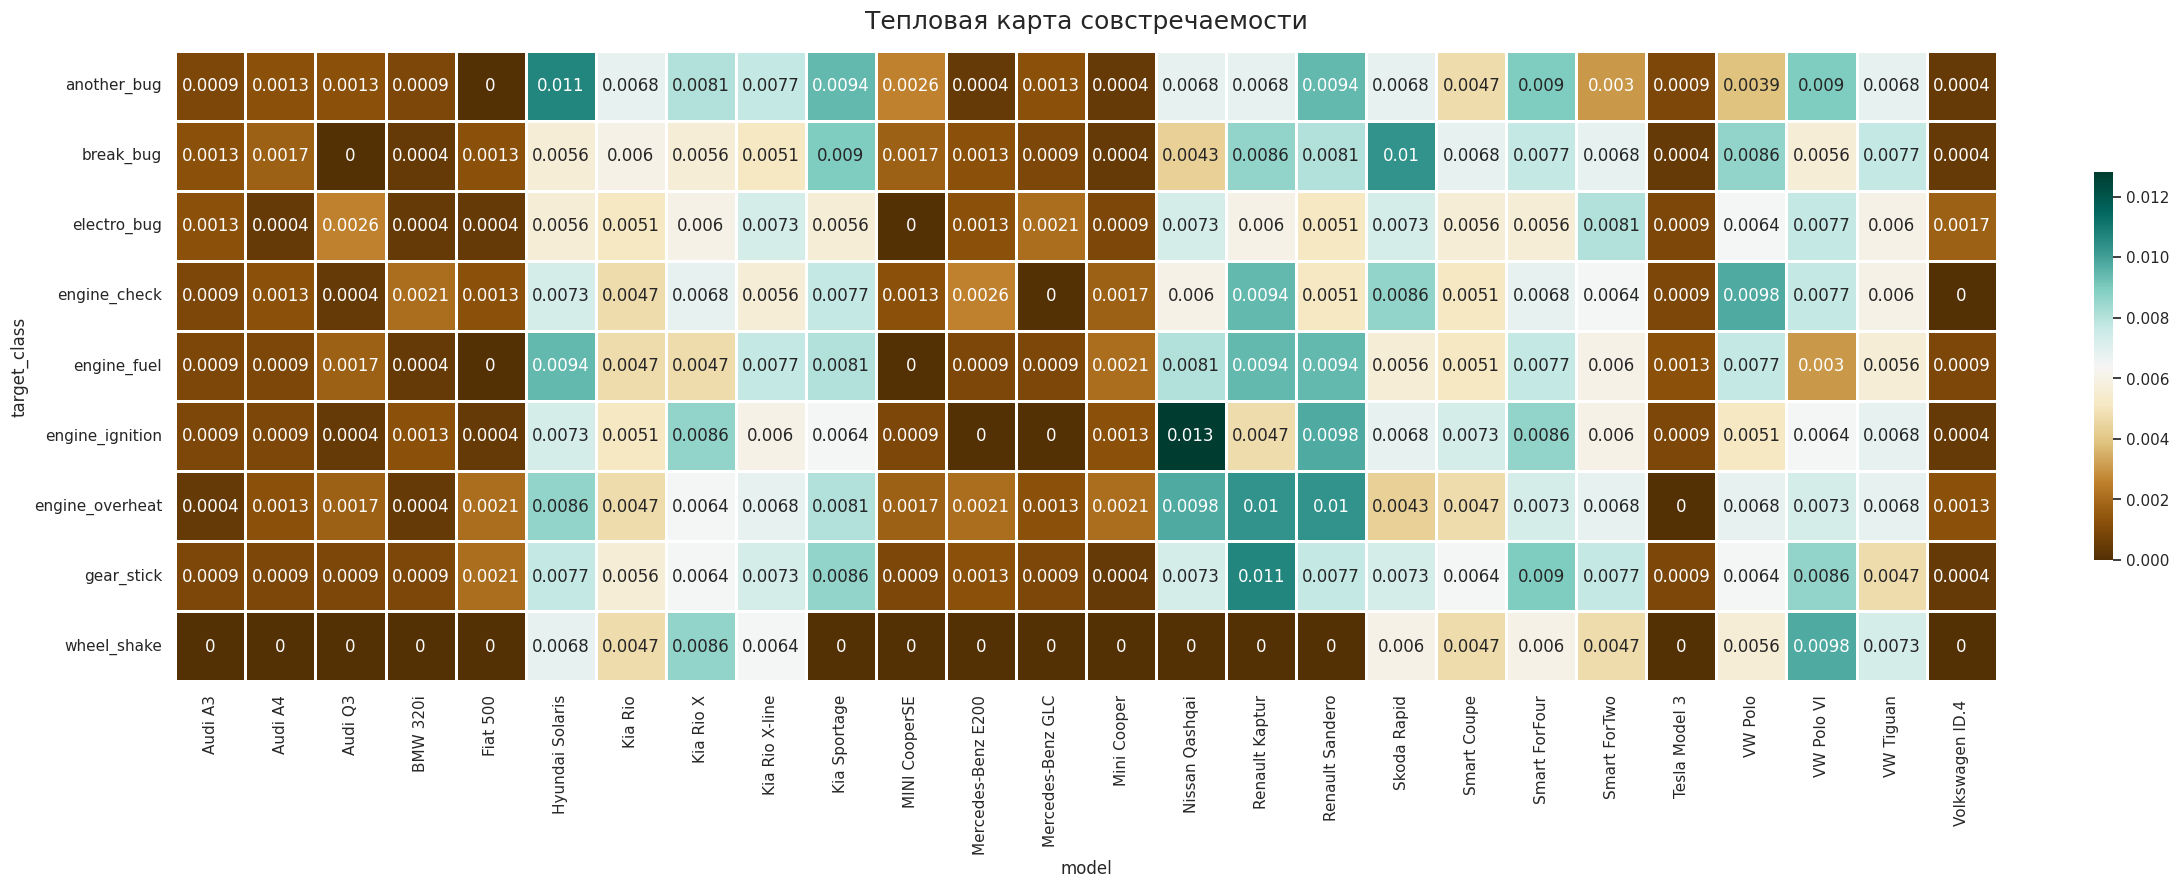

In [30]:
crst = pd.crosstab(
    rides_info["target_class"],
    rides_info["model"],
    normalize=True,
).round(4)


heatmap = sns.heatmap(
    crst,
    annot=True,
    square=True,
    cmap="BrBG",
    cbar_kws={"fraction": 0.01},
    linewidth=1,
)

heatmap.set_title("Тепловая карта совстречаемости", fontdict={"fontsize": 18}, pad=16);

# <center> 🔥 Парные зависимости между переменными и <b> `sns.pairplot()` </b></center>

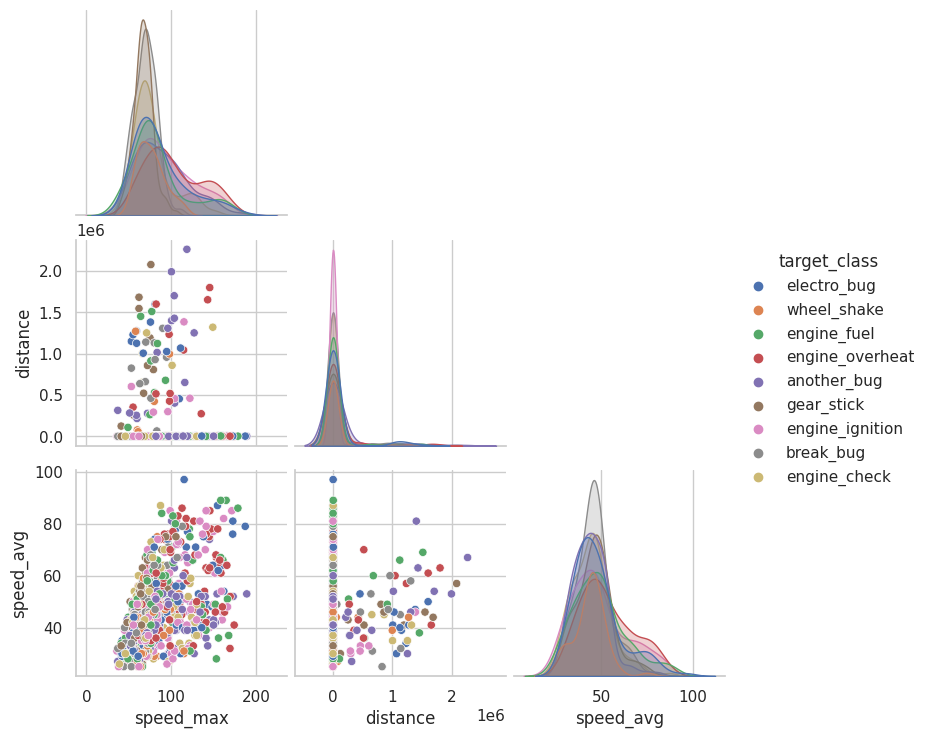

In [31]:
sns.pairplot(
    rides_info.sample(1000),
    vars=["speed_max", "distance", "speed_avg"],
    corner=True,
    hue="target_class",
);

# <center> `sns.lmplot` = `sns.pairplot` + умение провести прямую </center> 

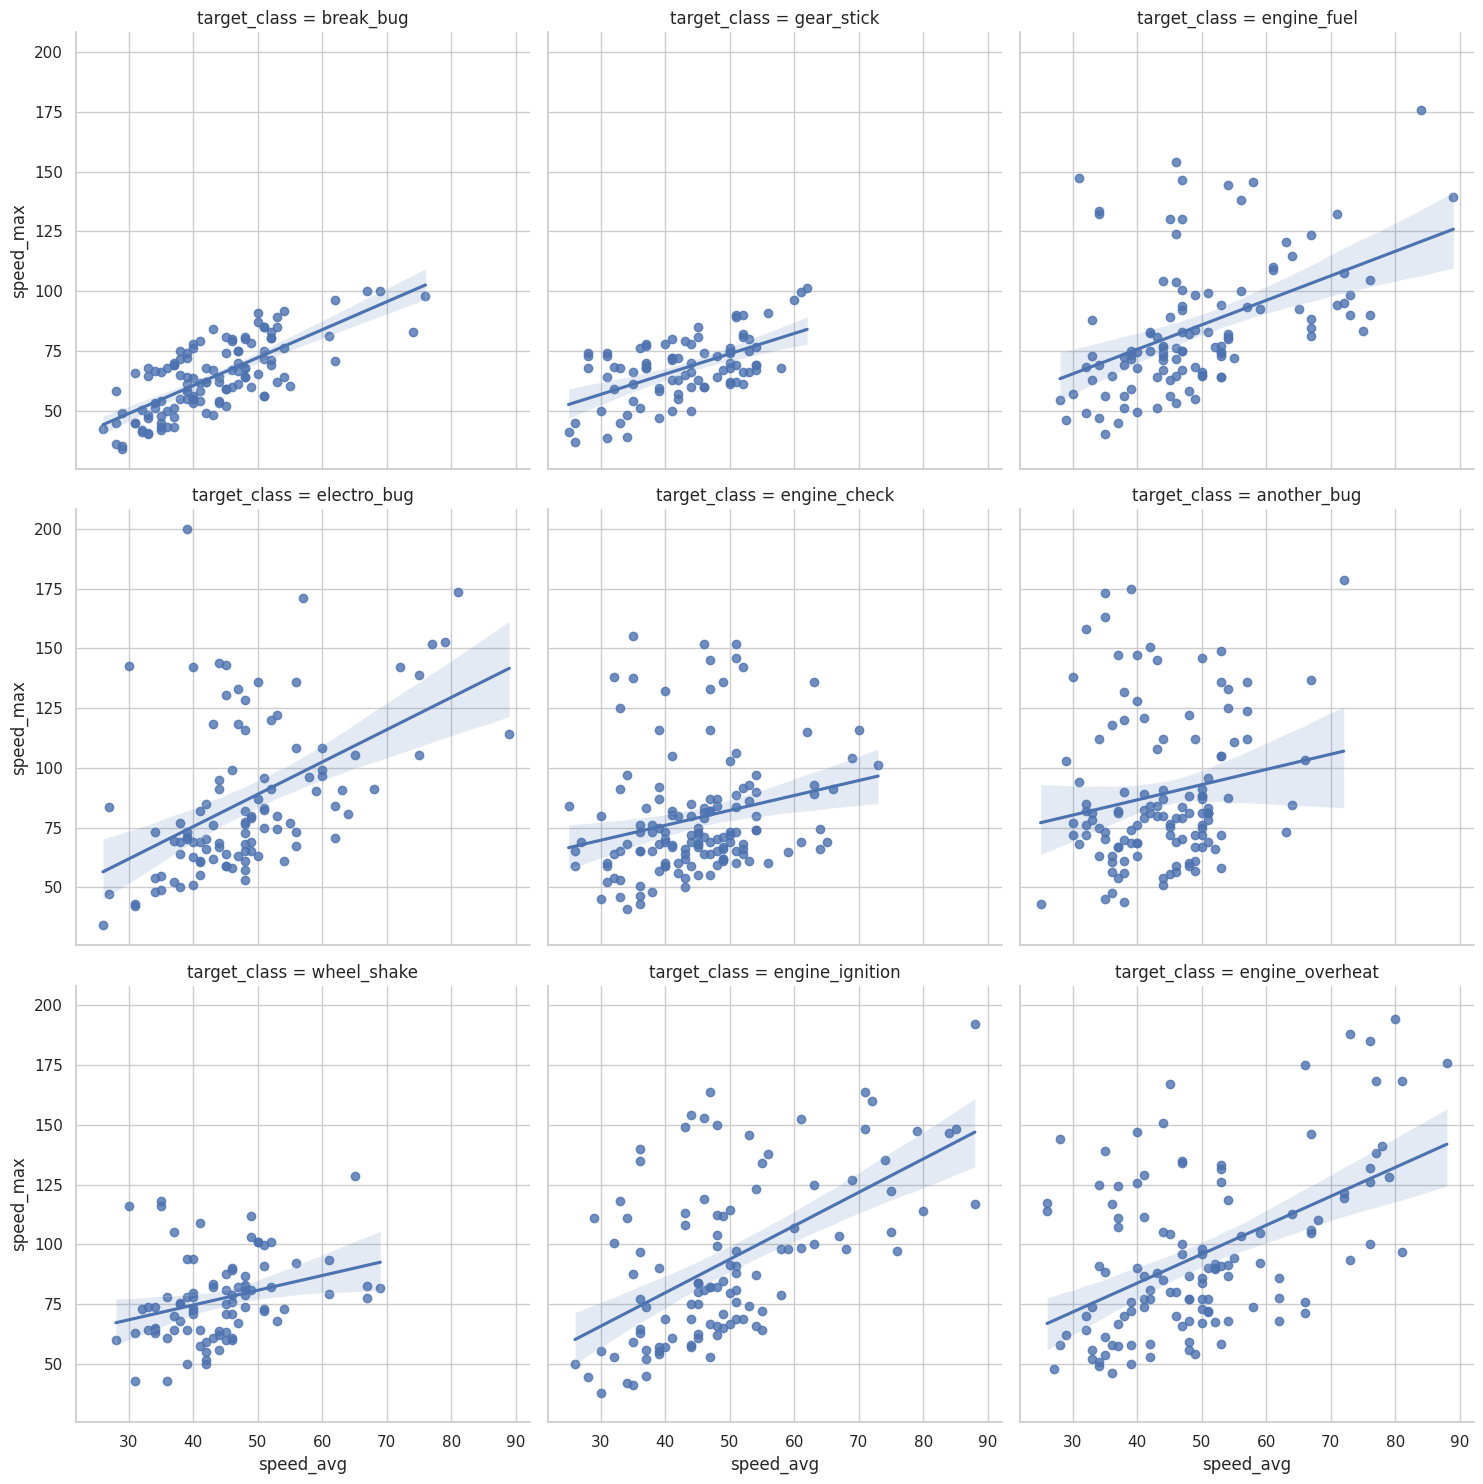

In [32]:
sns.lmplot(
    data=rides_info.sample(1000),
    x="speed_avg",
    y="speed_max",
    
    col="target_class",
    
    col_wrap=3,
);

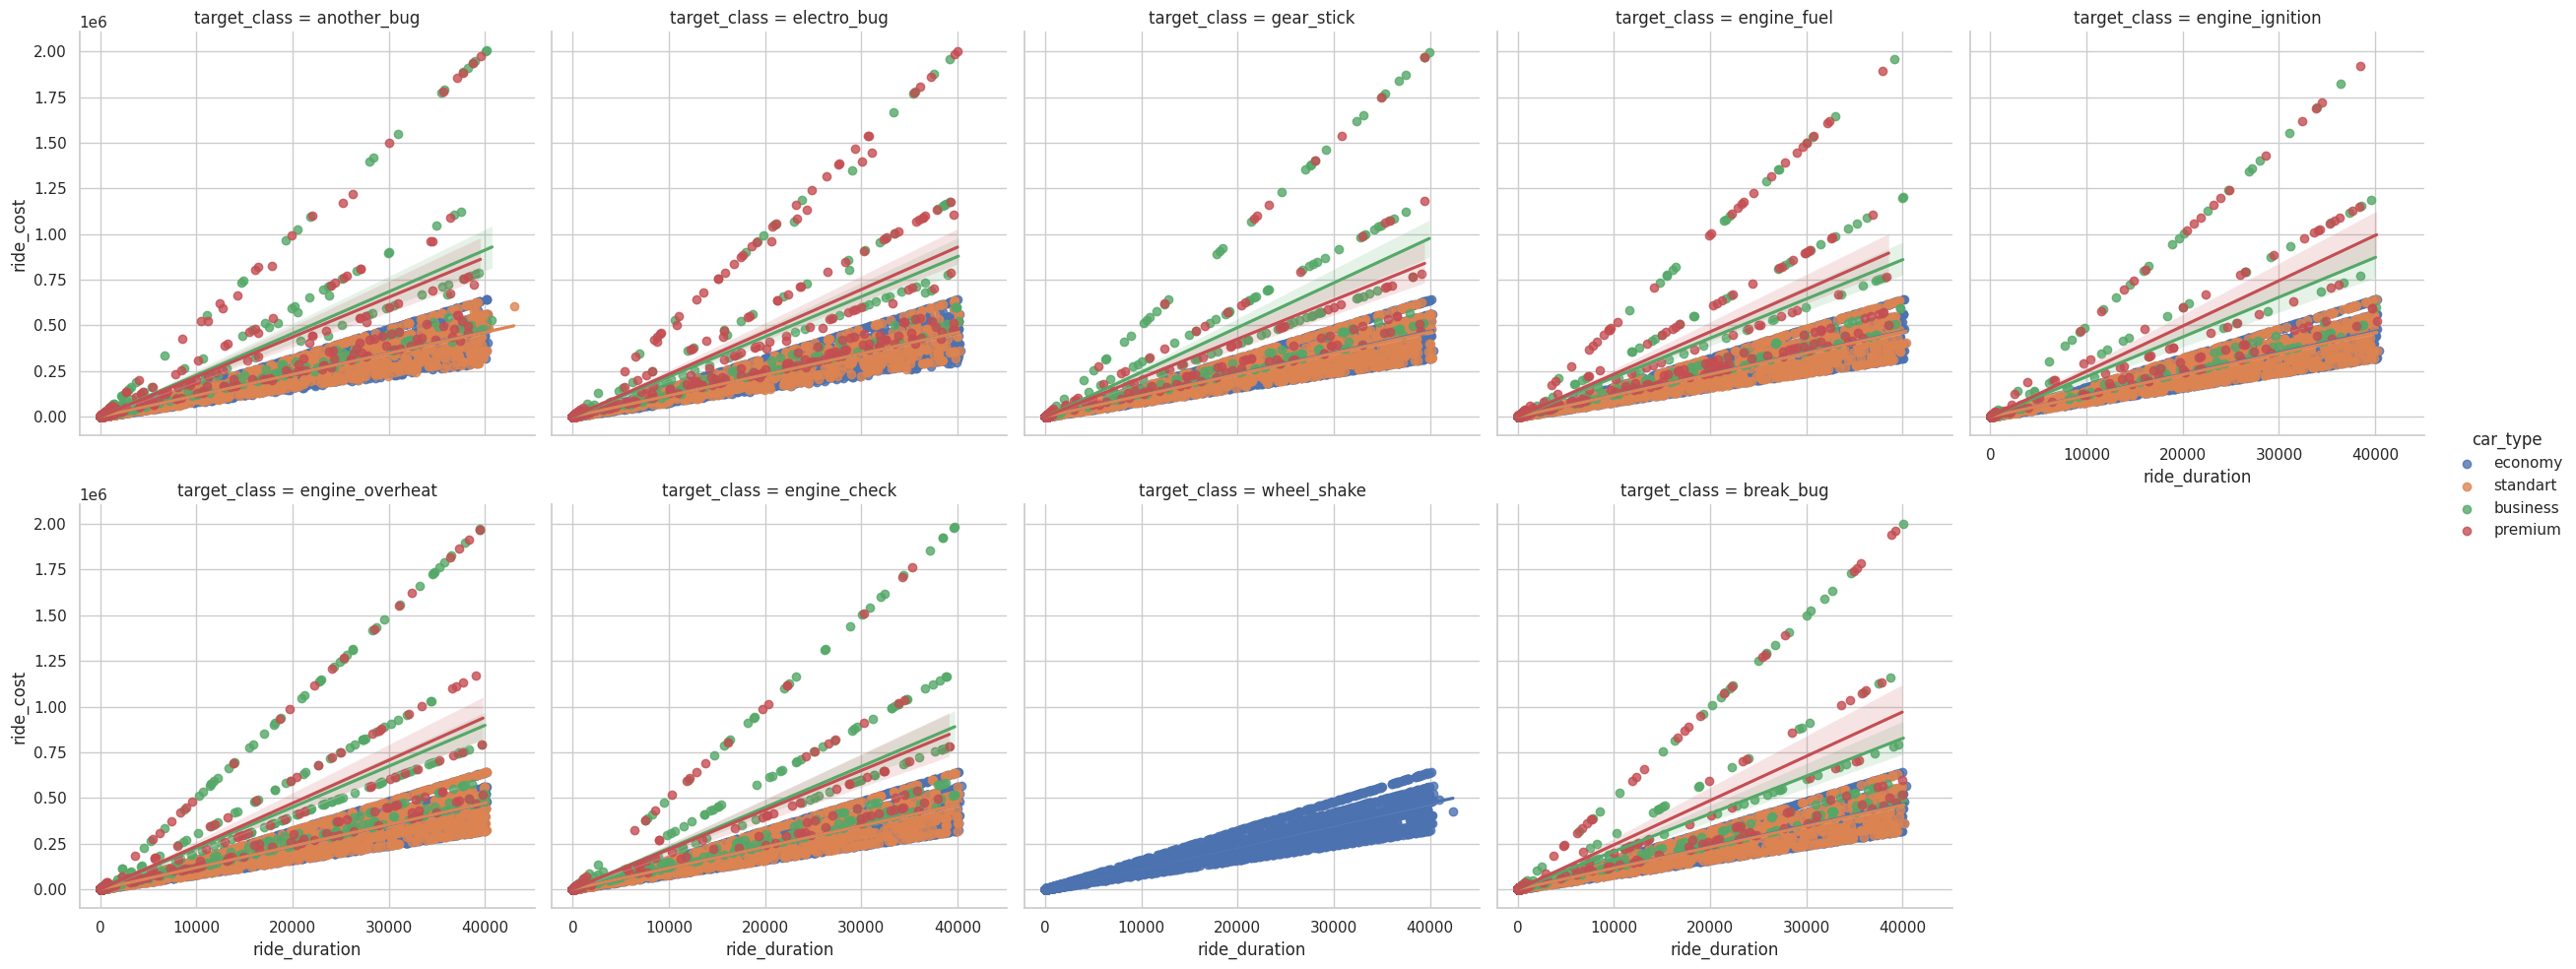

In [33]:
sns.lmplot(
    data=rides_info,
    x="ride_duration",
    y="ride_cost",
    col="target_class",
    
    hue="car_type",
    
    col_wrap=5,
);

# <center>Композиция нескольких видов графиков и <b> `sns.jointplot()`</b></center> 

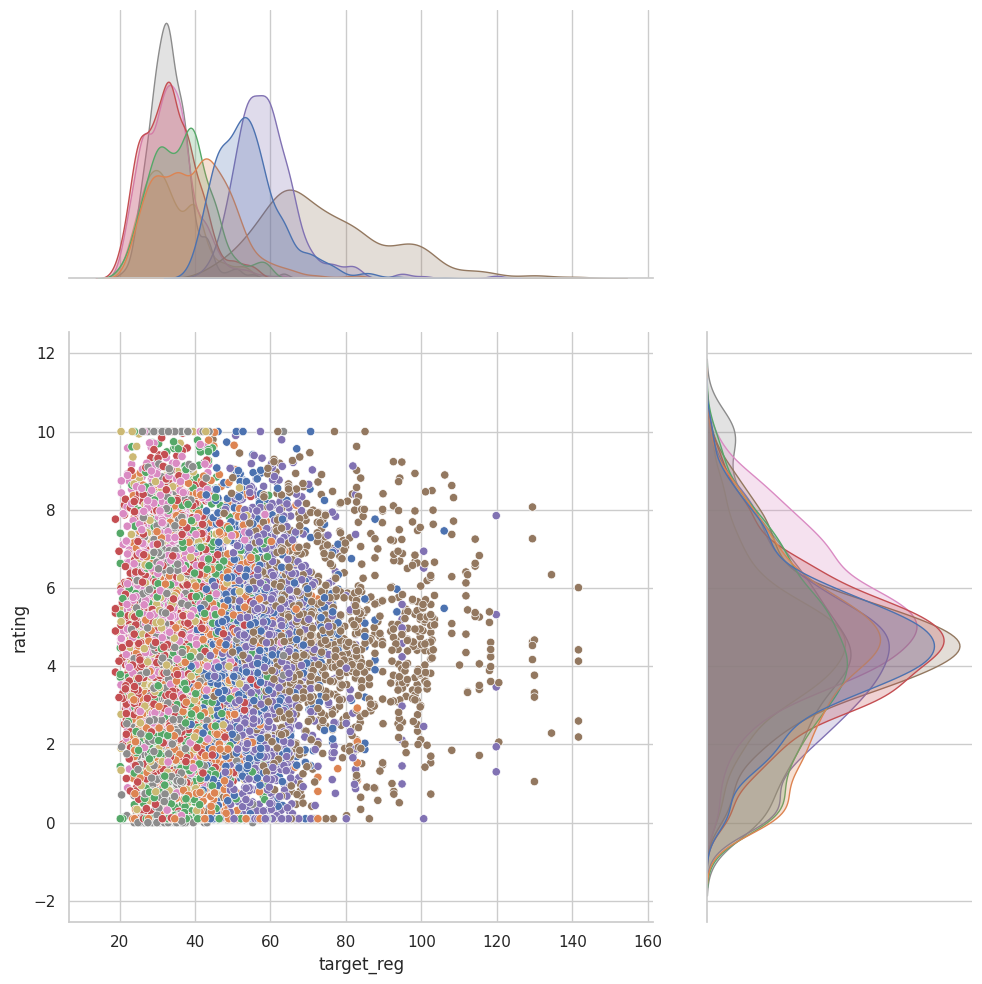

In [34]:
# Диаграмма рассеяния + распределения

sns.jointplot(
    data=rides_info.sample(10_000),
    x="target_reg",
    y="rating",
    hue="target_class",
    height=10,
    legend=False,
    ratio=2,
    kind="scatter",
);

### Карта графики Seaborn
<center> <img src = 'https://martinnormark.com/content/images/size/w2400/2020/10/2VmgDnF.png' width=1000>

# Итоги и выводы:

- Способов визуализации много. Иногда можно даже не выходить из `Pandas`
- `Seaborn` очень функциональный и понятный фреймворк. Для соревновательноо DS этого достаточно.
- Запомните хотя бы три самых важных для себя функции и пользуйтесь

__например__: `sns.relplot` / `sns.displot` / `sns.heatmap`

- Растягивайте признак по времени, по частоте или другому признаку.
- Раскрашивайте в таргет!

# <center> Спасибо за внимание! </center>